<a href="https://colab.research.google.com/github/GhostLIoyd/Df_Meteor_Shower_Activity_Signals_and_Background_Separation_Based_on_Time_Series_Anomaly_Analysis/blob/main/Detection_of_Meteor_Shower_Activity_Signals_and_Background_Separation_Based_on_Time_Series_Anomaly_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from scipy import stats
from scipy.signal import find_peaks

print("Environment initialized successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Environment initialized successfully.
NumPy version: 2.1.3
Pandas version: 2.2.3


In [ ]:
# Cell 2: Project configuration

PROJECT_NAME = "Meteor Shower Activity Anomaly Detection"

# Time resolution for the meteor activity time series
# We will start with daily counts and can later change to hourly.
TIME_RESOLUTION = "1D"

# Anomaly detection parameters
Z_THRESHOLD = 3.0
ROLLING_WINDOW = 7

# Data sources
DATA_SOURCES = {
    "optical": "Optical Meteor Observations",
    "radio": "Radio Meteor Observations",
    "imo": "IMO Visual Meteor Database",
    "iau": "IAU Meteor Data Center",
    "gmn": "Global Meteor Network"
}

print(f"Project: {PROJECT_NAME}")
print(f"Time resolution: {TIME_RESOLUTION}")
print(f"Initial anomaly threshold: Z > {Z_THRESHOLD}")
print(f"Rolling window: {ROLLING_WINDOW} days")

Project: Meteor Shower Activity Anomaly Detection
Time resolution: 1D
Initial anomaly threshold: Z > 3.0
Rolling window: 7 days


In [ ]:
# Cell 3: Standard meteor-event data structure

# All meteor observations will eventually be converted
# into this standardized format.

METEOR_COLUMNS = [
    "timestamp",
    "source",
    "shower",
    "magnitude",
    "duration",
    "latitude",
    "longitude"
]

# Empty standardized DataFrame
meteor_data = pd.DataFrame(columns=METEOR_COLUMNS)

# Make sure timestamp will use pandas datetime format
meteor_data["timestamp"] = pd.to_datetime(
    meteor_data["timestamp"]
)

print("Standard meteor-event data structure created.")
print()
print("Expected columns:")
for column in METEOR_COLUMNS:
    print(f"  - {column}")

Standard meteor-event data structure created.

Expected columns:
  - timestamp
  - source
  - shower
  - magnitude
  - duration
  - latitude
  - longitude


In [ ]:
# Cell 4: Test the IMO Visual Meteor Database API

import requests
import json

# IMO VMDB API endpoint
API_URL = "https://www.imo.net/members/vmdb_open_api"

print("Testing IMO VMDB API...")
print(f"Endpoint: {API_URL}")

try:
    response = requests.get(API_URL, timeout=15)

    print(f"\nHTTP status code: {response.status_code}")
    print(f"Response type: {response.headers.get('content-type', 'unknown')}")

    # Display only the first part of the response
    print("\nResponse preview:")
    print(response.text[:1000])

except requests.exceptions.RequestException as e:
    print("\nAPI request failed.")
    print("Error:", e)

Testing IMO VMDB API...
Endpoint: https://www.imo.net/members/vmdb_open_api

HTTP status code: 200
Response type: text/html

Response preview:
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1, viewport-fit=cover">
  <meta name="robots" content="noindex,nofollow">
  <meta name="theme-color" content="#05121c">

  <title>International Meteor Organization &mdash; temporarily offline</title>

  <style>
    :root {
      color-scheme: dark;
      --night: #05121c;
      --abyss: #08202f;
      --panel: rgba(14, 37, 54, .86);
      --text: #eaf1ff;
      --muted: #a6bdcf;
      --line: rgba(143, 233, 242, .22);
      --aqua: #67d8e7;
      --button-text: #052029;
    }

    * {
      box-sizing: border-box;
    }

    html {
      min-height: 100%;
      background: var(--night);
    }

    body {
      min-height: 100vh;
      min-height: 100svh;
      margin: 0;
      padding:
        max(20px, env(safe-are

In [ ]:
# Cell 5: Check available IMO data resources

resources = {
    "IMO main website": "https://www.imo.net/",
    "IMO databases": "https://www.imo.net/resources/databases/",
    "IMO video meteor data": "https://www.imo.net/observations/methods/video-observation/data/",
    "IMO VMDB API": "https://www.imo.net/members/vmdb_open_api",
}

for name, url in resources.items():
    try:
        r = requests.get(url, timeout=15)

        print(f"{name}")
        print(f"  URL: {url}")
        print(f"  Status: {r.status_code}")
        print(f"  Content-Type: {r.headers.get('content-type', 'unknown')}")
        print()

    except Exception as e:
        print(f"{name}")
        print(f"  ERROR: {e}")
        print()

IMO main website
  URL: https://www.imo.net/
  Status: 200
  Content-Type: text/html

IMO databases
  URL: https://www.imo.net/resources/databases/
  Status: 200
  Content-Type: text/html

IMO video meteor data
  URL: https://www.imo.net/observations/methods/video-observation/data/
  Status: 200
  Content-Type: text/html

IMO VMDB API
  URL: https://www.imo.net/members/vmdb_open_api
  Status: 200
  Content-Type: text/html



In [ ]:
# Cell 6: Test NASA CNEOS Fireball API

import requests
import pandas as pd

CNEOS_URL = "https://ssd-api.jpl.nasa.gov/fireball.api"

print("Testing NASA CNEOS Fireball API...")
print(f"Endpoint: {CNEOS_URL}")

try:
    response = requests.get(CNEOS_URL, timeout=20)

    print(f"\nHTTP status code: {response.status_code}")
    print(f"Content-Type: {response.headers.get('content-type', 'unknown')}")

    if response.status_code == 200:
        data = response.json()

        print("\nTop-level keys:")
        print(list(data.keys()))

        print("\nFields:")
        print(data.get("fields"))

        print("\nNumber of records:")
        print(len(data.get("data", [])))

        print("\nFirst record:")
        if data.get("data"):
            print(data["data"][0])

    else:
        print("\nRequest failed.")
        print(response.text[:1000])

except requests.exceptions.RequestException as e:
    print("\nConnection error:")
    print(e)

except ValueError as e:
    print("\nResponse was not valid JSON:")
    print(e)

Testing NASA CNEOS Fireball API...
Endpoint: https://ssd-api.jpl.nasa.gov/fireball.api

HTTP status code: 200
Content-Type: application/json

Top-level keys:
['signature', 'count', 'fields', 'data']

Fields:
['date', 'energy', 'impact-e', 'lat', 'lat-dir', 'lon', 'lon-dir', 'alt', 'vel']

Number of records:
1073

First record:
['2026-09-15 11:26:13', '2.2', '0.079', '37.6', 'S', '161.6', 'W', '37.0', None]


In [ ]:
# Cell 7: Convert CNEOS data into a DataFrame

if "data" in locals() and data.get("data"):

    cneos_df = pd.DataFrame(
        data["data"],
        columns=data["fields"]
    )

    print("CNEOS DataFrame created successfully.")
    print(f"Shape: {cneos_df.shape}")

    display(cneos_df.head())

    print("\nData types:")
    display(cneos_df.dtypes)

else:
    print("No CNEOS data available.")

CNEOS DataFrame created successfully.
Shape: (1073, 9)


,date,energy,impact-e,lat,lat-dir,lon,lon-dir,alt,vel
0,2026-09-15 11:26:13,2.2,0.079,37.6,S,161.6,W,37.0,None
1,2026-09-11 10:18:03,6.1,0.2,0.2,S,129.6,W,70.0,None
2,2026-09-11 01:12:11,24.6,0.67,54.4,N,100.1,W,38.0,None
3,2026-09-10 05:22:22,11.1,0.33,19.3,S,28.1,W,33.6,19.3
4,2026-08-15 07:32:40,3.9,0.13,4.0,N,115.4,W,37.0,None



Data types:


,0
date,object
energy,object
impact-e,object
lat,object
lat-dir,object
lon,object
lon-dir,object
alt,object
vel,object


Cleaned CNEOS dataset
Records: 1073
Date range: 1988-04-15 03:03:10 → 2026-09-15 11:26:13

Missing values:


,0
date,0
energy,0
impact-e,0
lat,186
lat-dir,186
lon,186
lon-dir,186
alt,472
vel,712


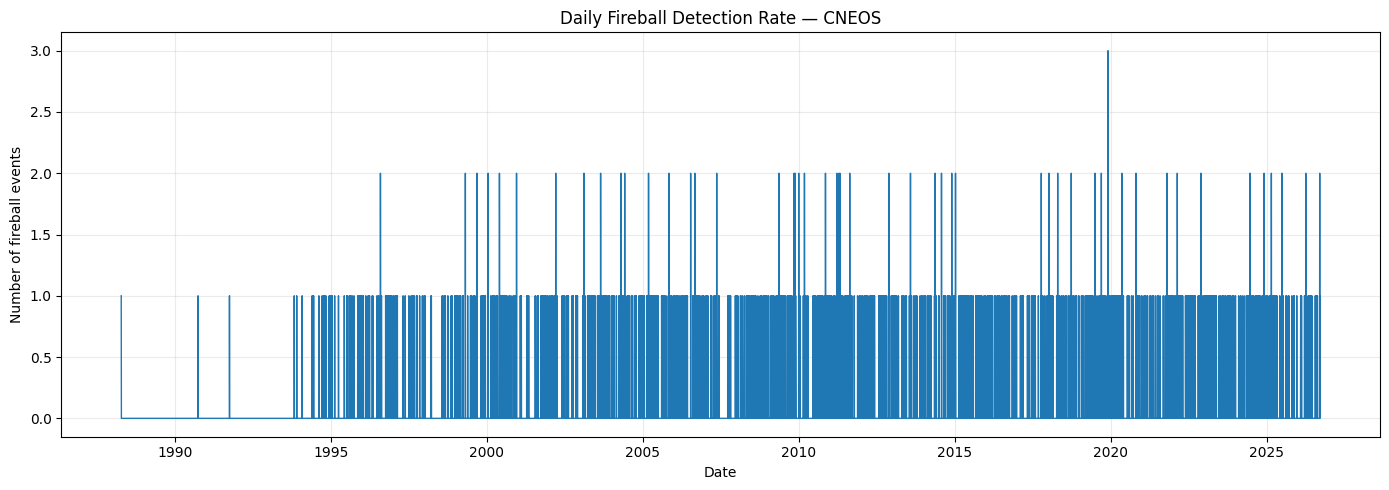

In [ ]:
# Cell 8: Clean CNEOS data and visualize the temporal distribution

# Make a copy so the original API data remains unchanged
cneos_clean = cneos_df.copy()

# Convert date to datetime
cneos_clean["date"] = pd.to_datetime(
    cneos_clean["date"],
    errors="coerce"
)

# Convert numerical columns to numeric
numeric_columns = [
    "energy",
    "impact-e",
    "lat",
    "lon",
    "alt",
    "vel"
]

for col in numeric_columns:
    cneos_clean[col] = pd.to_numeric(
        cneos_clean[col],
        errors="coerce"
    )

# Remove records without a valid timestamp
cneos_clean = cneos_clean.dropna(
    subset=["date"]
).sort_values("date")

print("Cleaned CNEOS dataset")
print(f"Records: {len(cneos_clean)}")
print(f"Date range: {cneos_clean['date'].min()} → {cneos_clean['date'].max()}")

print("\nMissing values:")
display(cneos_clean.isna().sum())

# ---------------------------------------------------------
# Aggregate fireball events by day
# ---------------------------------------------------------

daily_fireballs = (
    cneos_clean
    .set_index("date")
    .resample("1D")
    .size()
    .rename("fireball_count")
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    daily_fireballs.index,
    daily_fireballs.values,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Number of fireball events")
plt.title("Daily Fireball Detection Rate — CNEOS")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9: Basic statistics of the CNEOS fireball time series

# ---------------------------------------------------------
# Basic statistics
# ---------------------------------------------------------

print("CNEOS Fireball Time-Series Statistics")
print("=" * 50)

print(f"Total events: {len(cneos_clean)}")
print(f"Start date:   {cneos_clean['date'].min()}")
print(f"End date:     {cneos_clean['date'].max()}")

# Number of days covered
date_span = (
    cneos_clean["date"].max().normalize()
    - cneos_clean["date"].min().normalize()
).days + 1

print(f"Observation span: {date_span:,} days")

# Daily statistics
print("\nDaily fireball count statistics:")
print(daily_fireballs.describe())

# Number of active days
active_days = (daily_fireballs > 0).sum()

print(f"\nDays with at least one detected fireball: {active_days:,}")
print(
    f"Percentage of active days: "
    f"{active_days / len(daily_fireballs) * 100:.2f}%"
)

CNEOS Fireball Time-Series Statistics
Total events: 1073
Start date:   1988-04-15 03:03:10
End date:     2026-09-15 11:26:13
Observation span: 14,033 days

Daily fireball count statistics:
count    14033.000000
mean         0.076463
std          0.279343
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: fireball_count, dtype: float64

Days with at least one detected fireball: 1,022
Percentage of active days: 7.28%


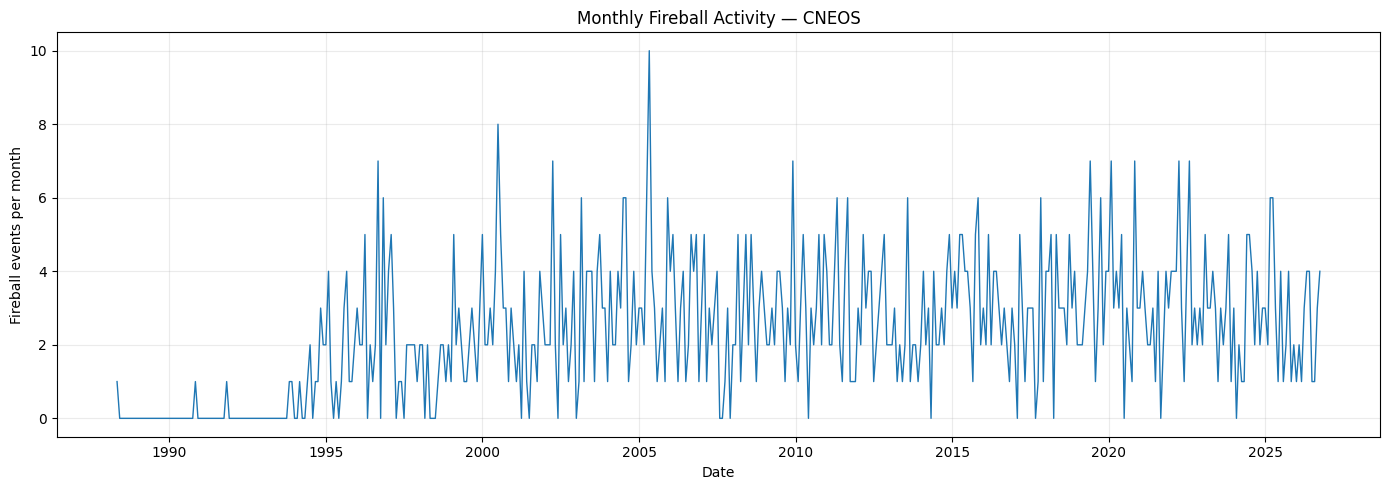

Yearly fireball counts:


,fireball_count
date,
1988-12-31,1
1989-12-31,0
1990-12-31,1
1991-12-31,1
1992-12-31,0
1993-12-31,2
1994-12-31,13
1995-12-31,21
1996-12-31,33


In [ ]:
# Cell 10: Visualize the long-term CNEOS fireball activity

# ---------------------------------------------------------
# Aggregate fireballs by month
# ---------------------------------------------------------

monthly_fireballs = (
    cneos_clean
    .set_index("date")
    .resample("ME")
    .size()
    .rename("fireball_count")
)

# ---------------------------------------------------------
# Aggregate fireballs by year
# ---------------------------------------------------------

yearly_fireballs = (
    cneos_clean
    .set_index("date")
    .resample("YE")
    .size()
    .rename("fireball_count")
)

# ---------------------------------------------------------
# Plot monthly activity
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_fireballs.index,
    monthly_fireballs.values,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Fireball events per month")
plt.title("Monthly Fireball Activity — CNEOS")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print yearly statistics
# ---------------------------------------------------------

print("Yearly fireball counts:")
display(yearly_fireballs.to_frame())

In [ ]:
# Cell 11: Test access to the Global Meteor Network (GMN) data

import requests

GMN_BASE_URL = "https://globalmeteornetwork.org/data/traj_summary_data/"

print("Testing Global Meteor Network data access...")
print(f"URL: {GMN_BASE_URL}")

try:
    response = requests.get(
        GMN_BASE_URL,
        timeout=20
    )

    print(f"\nHTTP status code: {response.status_code}")
    print(
        f"Content-Type: "
        f"{response.headers.get('content-type', 'unknown')}"
    )

    print("\nResponse preview:")
    print(response.text[:2000])

except requests.exceptions.RequestException as e:
    print("\nGMN request failed.")
    print("Error:", e)

Testing Global Meteor Network data access...
URL: https://globalmeteornetwork.org/data/traj_summary_data/

HTTP status code: 200
Content-Type: text/html

Response preview:
<html>
<head><title>Index of /data/traj_summary_data/</title></head>
<body>
<h1>Index of /data/traj_summary_data/</h1><hr><pre><a href="../">../</a>
<a href="daily/">daily/</a>                                             17-Sep-2026 06:54       -
<a href="monthly/">monthly/</a>                                           01-Sep-2026 16:34       -
<a href="traj_summary_all.txt">traj_summary_all.txt</a>                               17-Sep-2026 12:32      3G
<a href="traj_summary_yearly_2018.txt">traj_summary_yearly_2018.txt</a>                       17-Sep-2026 12:25    449K
<a href="traj_summary_yearly_2019.txt">traj_summary_yearly_2019.txt</a>                       17-Sep-2026 12:25     44M
<a href="traj_summary_yearly_2020.txt">traj_summary_yearly_2020.txt</a>                       17-Sep-2026 12:25    110M
<a href="

In [ ]:
# Cell 12: Inspect the GMN monthly data directory

GMN_MONTHLY_URL = (
    "https://globalmeteornetwork.org/data/"
    "traj_summary_data/monthly/"
)

print("Checking GMN monthly data directory...")
print(f"URL: {GMN_MONTHLY_URL}")

try:
    response = requests.get(
        GMN_MONTHLY_URL,
        timeout=20
    )

    print(f"\nHTTP status code: {response.status_code}")
    print(
        f"Content-Type: "
        f"{response.headers.get('content-type', 'unknown')}"
    )

    print("\nAvailable files:")
    print(response.text[:5000])

except requests.exceptions.RequestException as e:
    print("\nRequest failed.")
    print("Error:", e)

Checking GMN monthly data directory...
URL: https://globalmeteornetwork.org/data/traj_summary_data/monthly/

HTTP status code: 200
Content-Type: text/html

Available files:
<html>
<head><title>Index of /data/traj_summary_data/monthly/</title></head>
<body>
<h1>Index of /data/traj_summary_data/monthly/</h1><hr><pre><a href="../">../</a>
<a href="traj_summary_monthly_201812.txt">traj_summary_monthly_201812.txt</a>                    16-Jun-2023 11:42    449K
<a href="traj_summary_monthly_201901.txt">traj_summary_monthly_201901.txt</a>                    16-Jun-2023 11:42    511K
<a href="traj_summary_monthly_201902.txt">traj_summary_monthly_201902.txt</a>                    16-Jun-2023 11:42      1M
<a href="traj_summary_monthly_201903.txt">traj_summary_monthly_201903.txt</a>                    16-Jun-2023 11:41    486K
<a href="traj_summary_monthly_201904.txt">traj_summary_monthly_201904.txt</a>                    16-Jun-2023 11:41    793K
<a href="traj_summary_monthly_201905.txt">traj_

In [ ]:
# Cell 13: Inspect the structure of multiple GMN monthly files

import requests
import re

GMN_MONTHLY_BASE = (
    "https://globalmeteornetwork.org/data/"
    "traj_summary_data/monthly/"
)

# We inspect several files from different periods.
# This helps us make sure the format is consistent over time.
TEST_FILES = [
    "traj_summary_monthly_201901.txt",
    "traj_summary_monthly_202001.txt",
    "traj_summary_monthly_202101.txt",
    "traj_summary_monthly_202201.txt",
    "traj_summary_monthly_202301.txt",
    "traj_summary_monthly_202401.txt",
    "traj_summary_monthly_202501.txt"
]

print("Inspecting GMN monthly data structure")
print("=" * 80)

for filename in TEST_FILES:

    url = GMN_MONTHLY_BASE + filename

    try:
        response = requests.get(
            url,
            timeout=30
        )

        print(f"\nFile: {filename}")
        print(f"HTTP status: {response.status_code}")
        print(
            f"Downloaded size: "
            f"{len(response.content) / (1024 * 1024):.2f} MB"
        )

        if response.status_code != 200:
            print("Download failed.")
            continue

        # Only inspect the beginning of the file.
        # We do NOT keep the entire file in memory.
        text = response.content[:20000].decode(
            "utf-8",
            errors="replace"
        )

        lines = text.splitlines()

        print("\nFirst 12 non-empty lines:")
        print("-" * 80)

        shown = 0

        for line in lines:

            if not line.strip():
                continue

            print(line[:500])
            shown += 1

            if shown >= 12:
                break

        print("-" * 80)

    except requests.exceptions.RequestException as e:

        print(f"\nFile: {filename}")
        print("Request failed:")
        print(e)

print("\nInspection completed.")

Inspecting GMN monthly data structure

File: traj_summary_monthly_201901.txt
HTTP status: 200
Downloaded size: 0.50 MB

First 12 non-empty lines:
--------------------------------------------------------------------------------
# Summary generated on 2023-06-16 11:42:20.487628 UTC
#  Unique trajectory;      Beginning      ;        Beginning          ;   IAU;  IAU;   Sol lon ;   App LST ;   RAgeo  ;   +/-  ;   DECgeo ;   +/-  ;  LAMgeo  ;   +/-  ;   BETgeo ;   +/-  ;    Vgeo  ;    +/- ;  LAMhel  ;   +/-  ;   BEThel ;   +/-  ;    Vhel  ;    +/- ;       a    ;   +/-  ;      e    ;   +/-  ;      i    ;   +/-  ;    peri   ;    +/-  ;    node   ;    +/-  ;     Pi    ;   +/-  ;      b    ;   +/-  ;      q    ;   +/-  ;      f    ;   +/-  ;      M    ;   +/-  ;       Q    ;   +/-
#      identifier   ;     Julian date     ;         UTC Time          ;    No; code;     deg   ;     deg   ;    deg   ;  sigma ;    deg   ;  sigma ;    deg   ;  sigma ;     deg  ;  sigma ;    km/s  ;   sigma;    deg   

In [ ]:
# Cell 14: Download and preprocess GMN monthly data (2019–2025)

import requests
import pandas as pd
import io
import time

# ---------------------------------------------------------
# GMN data configuration
# ---------------------------------------------------------

GMN_MONTHLY_BASE = (
    "https://globalmeteornetwork.org/data/"
    "traj_summary_data/monthly/"
)

START_YEAR = 2019
END_YEAR = 2025

# Columns that we need for the main analysis
# Based on the GMN monthly file structure inspected in Cell 13
USE_COLUMNS = [
    "identifier",
    "Julian date",
    "UTC Time",
    "No",
    "code",
    "Sol lon"
]

all_monthly_data = []
download_log = []

print("Starting GMN bulk data download")
print("=" * 70)
print(f"Period: {START_YEAR}-01 to {END_YEAR}-12")
print("Total months:", (END_YEAR - START_YEAR + 1) * 12)
print()

# ---------------------------------------------------------
# Download month by month
# ---------------------------------------------------------

for year in range(START_YEAR, END_YEAR + 1):

    for month in range(1, 13):

        filename = f"traj_summary_monthly_{year}{month:02d}.txt"
        url = GMN_MONTHLY_BASE + filename

        print(f"[{year}-{month:02d}] Downloading {filename} ...")

        try:
            response = requests.get(
                url,
                timeout=120
            )

            if response.status_code != 200:
                print(
                    f"   FAILED — HTTP {response.status_code}"
                )

                download_log.append({
                    "file": filename,
                    "status": response.status_code,
                    "size_MB": 0
                })

                continue

            file_size_mb = len(response.content) / (1024 * 1024)

            # -------------------------------------------------
            # GMN files are semicolon-separated.
            # Header begins with "#" and data begins afterwards.
            # -------------------------------------------------

            text = response.content.decode(
                "utf-8",
                errors="replace"
            )

            lines = text.splitlines()

            data_lines = [
                line for line in lines
                if line.strip() and not line.lstrip().startswith("#")
            ]

            if not data_lines:
                print("   FAILED — no data rows found")
                continue

            # Read the semicolon-separated data
            month_df = pd.read_csv(
                io.StringIO("\n".join(data_lines)),
                sep=";",
                header=None,
                dtype=str
            )

            # The GMN format contains 40+ columns.
            # We use only the first six relevant columns.
            month_df = month_df.iloc[:, :6].copy()

            month_df.columns = USE_COLUMNS

            # -------------------------------------------------
            # Basic cleaning
            # -------------------------------------------------

            month_df["UTC Time"] = pd.to_datetime(
                month_df["UTC Time"].str.strip(),
                errors="coerce"
            )

            month_df["Sol lon"] = pd.to_numeric(
                month_df["Sol lon"].str.strip(),
                errors="coerce"
            )

            month_df["No"] = pd.to_numeric(
                month_df["No"].str.strip(),
                errors="coerce"
            )

            month_df["code"] = (
                month_df["code"]
                .astype(str)
                .str.strip()
            )

            month_df = month_df.dropna(
                subset=["UTC Time"]
            )

            month_df["year"] = year
            month_df["month"] = month

            all_monthly_data.append(month_df)

            download_log.append({
                "file": filename,
                "status": 200,
                "size_MB": round(file_size_mb, 2),
                "records": len(month_df)
            })

            print(
                f"   OK — {file_size_mb:.2f} MB, "
                f"{len(month_df):,} records"
            )

        except Exception as e:

            print(f"   ERROR — {e}")

            download_log.append({
                "file": filename,
                "status": "ERROR",
                "size_MB": 0
            })

        # Small pause to avoid sending requests too quickly
        time.sleep(0.2)


# ---------------------------------------------------------
# Combine all months
# ---------------------------------------------------------

if all_monthly_data:

    gmn_data = pd.concat(
        all_monthly_data,
        ignore_index=True
    )

else:

    gmn_data = pd.DataFrame(
        columns=USE_COLUMNS + ["year", "month"]
    )


# ---------------------------------------------------------
# Sort chronologically
# ---------------------------------------------------------

gmn_data = gmn_data.sort_values(
    "UTC Time"
).reset_index(drop=True)


# ---------------------------------------------------------
# Download summary
# ---------------------------------------------------------

download_log_df = pd.DataFrame(download_log)

successful_files = (
    download_log_df["status"] == 200
).sum()

failed_files = len(download_log_df) - successful_files


print()
print("=" * 70)
print("GMN BULK DOWNLOAD COMPLETED")
print("=" * 70)

print(f"Successful months: {successful_files}")
print(f"Failed months:     {failed_files}")
print(f"Total records:     {len(gmn_data):,}")

if len(gmn_data) > 0:

    print(
        f"Date range: "
        f"{gmn_data['UTC Time'].min()} → "
        f"{gmn_data['UTC Time'].max()}"
    )

print()
print("Download summary:")
display(download_log_df)

print()
print("GMN dataset preview:")
display(gmn_data.head())

print()
print("Data types:")
display(gmn_data.dtypes)

Starting GMN bulk data download
Period: 2019-01 to 2025-12
Total months: 84

[2019-01] Downloading traj_summary_monthly_201901.txt ...
   OK — 0.50 MB, 564 records
[2019-02] Downloading traj_summary_monthly_201902.txt ...
   OK — 1.13 MB, 1,284 records
[2019-03] Downloading traj_summary_monthly_201903.txt ...
   OK — 0.47 MB, 537 records
[2019-04] Downloading traj_summary_monthly_201904.txt ...
   OK — 0.77 MB, 876 records
[2019-05] Downloading traj_summary_monthly_201905.txt ...
   OK — 1.10 MB, 1,242 records
[2019-06] Downloading traj_summary_monthly_201906.txt ...
   OK — 1.35 MB, 1,523 records
[2019-07] Downloading traj_summary_monthly_201907.txt ...
   OK — 1.73 MB, 1,961 records
[2019-08] Downloading traj_summary_monthly_201908.txt ...
   OK — 4.75 MB, 5,387 records
[2019-09] Downloading traj_summary_monthly_201909.txt ...
   OK — 5.35 MB, 6,058 records
[2019-10] Downloading traj_summary_monthly_201910.txt ...
   OK — 10.57 MB, 11,978 records
[2019-11] Downloading traj_summary_mo

,file,status,size_MB,records
0,traj_summary_monthly_201901.txt,200,0.50,564
1,traj_summary_monthly_201902.txt,200,1.13,1284
2,traj_summary_monthly_201903.txt,200,0.47,537
3,traj_summary_monthly_201904.txt,200,0.77,876
4,traj_summary_monthly_201905.txt,200,1.10,1242
...,...,...,...,...
79,traj_summary_monthly_202508.txt,200,111.62,125815
80,traj_summary_monthly_202509.txt,200,78.61,88586
81,traj_summary_monthly_202510.txt,200,85.11,96024
82,traj_summary_monthly_202511.txt,200,83.23,93761



GMN dataset preview:


,identifier,Julian date,UTC Time,No,code,Sol lon,year,month
0,20190101034424_54p5G,2458484.655843813438,2019-01-01 03:44:24.905481,-1,...,280.160012,2019,1
1,20190101040455_0h4Nf,2458484.670090174768,2019-01-01 04:04:55.791100,308,PIP,280.174535,2019,1
2,20190101072017_ydPyT,2458484.805760666728,2019-01-01 07:20:17.721605,-1,...,280.312845,2019,1
3,20190101073920_8VoS2,2458484.818985602818,2019-01-01 07:39:20.356084,-1,...,280.326328,2019,1
4,20190102091919_1KtJa,2458485.888420471922,2019-01-02 09:19:19.528774,-1,...,281.416625,2019,1



Data types:


,0
identifier,object
Julian date,object
UTC Time,datetime64[ns]
No,int64
code,object
Sol lon,float64
year,int64
month,int64


Building daily GMN meteor activity time series...

Daily time series created successfully.

Number of days: 2,557
Date range: 2019-01-01 → 2025-12-31

Total meteor records:
  2,845,801
Shower-associated records:
  801,004
Non-shower / unclassified records:
  2,044,797

Daily activity statistics:


,total_count,shower_count,non_shower_count
count,2557.000000,2557.000000,2557.000000
mean,1112.945248,313.259288,799.685960
std,1307.916202,757.671578,761.140691
min,0.000000,0.000000,0.000000
25%,279.000000,32.000000,228.000000
50%,680.000000,105.000000,523.000000
75%,1558.000000,318.000000,1165.000000
max,19224.000000,15525.000000,4022.000000



First 10 days:


,total_count,shower_count,non_shower_count
UTC Time,,,
2019-01-01,4,1,3
2019-01-02,6,0,6
2019-01-03,43,10,33
2019-01-04,18,7,11
2019-01-05,31,5,26
2019-01-06,0,0,0
2019-01-07,32,5,27
2019-01-08,0,0,0
2019-01-09,41,9,32


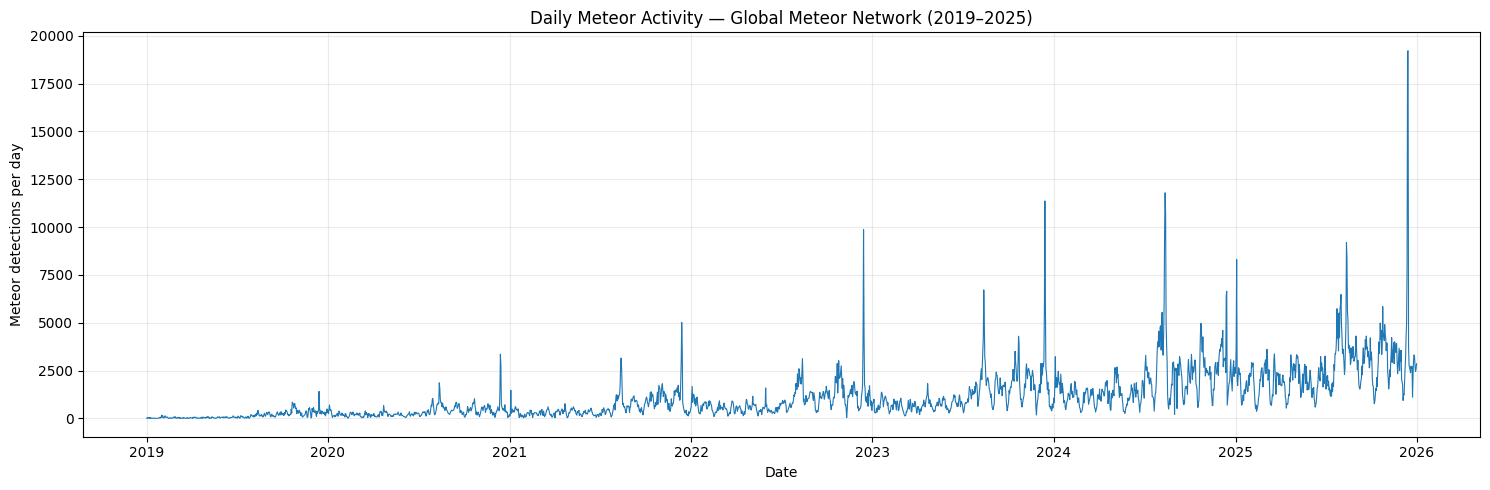

In [ ]:
# Cell 15: Construct daily meteor activity time series

print("Building daily GMN meteor activity time series...")
print("=" * 70)

# ---------------------------------------------------------
# 1. Create a clean working copy
# ---------------------------------------------------------

gmn_analysis = gmn_data[
    ["UTC Time", "code", "Sol lon"]
].copy()

# Make sure timestamp is datetime
gmn_analysis["UTC Time"] = pd.to_datetime(
    gmn_analysis["UTC Time"],
    errors="coerce"
)

# Remove invalid timestamps
gmn_analysis = gmn_analysis.dropna(
    subset=["UTC Time"]
)

# ---------------------------------------------------------
# 2. Define whether each meteor has a shower code
# ---------------------------------------------------------

# GMN uses "-1" / "..." for records without an assigned
# meteor-shower code in the downloaded data.

gmn_analysis["code_clean"] = (
    gmn_analysis["code"]
    .astype(str)
    .str.strip()
)

gmn_analysis["is_shower_associated"] = (
    ~gmn_analysis["code_clean"].isin([
        "-1",
        "...",
        "",
        "nan",
        "None"
    ])
)

# ---------------------------------------------------------
# 3. Daily total meteor counts
# ---------------------------------------------------------

daily_total = (
    gmn_analysis
    .set_index("UTC Time")
    .resample("1D")
    .size()
    .rename("total_count")
)

# ---------------------------------------------------------
# 4. Daily shower-associated meteor counts
# ---------------------------------------------------------

daily_shower = (
    gmn_analysis[
        gmn_analysis["is_shower_associated"]
    ]
    .set_index("UTC Time")
    .resample("1D")
    .size()
    .rename("shower_count")
)

# ---------------------------------------------------------
# 5. Combine the two time series
# ---------------------------------------------------------

daily_activity = pd.concat(
    [
        daily_total,
        daily_shower
    ],
    axis=1
).fillna(0)

daily_activity["non_shower_count"] = (
    daily_activity["total_count"]
    - daily_activity["shower_count"]
)

# ---------------------------------------------------------
# 6. Basic statistics
# ---------------------------------------------------------

print("\nDaily time series created successfully.")
print()

print(f"Number of days: {len(daily_activity):,}")
print(
    f"Date range: "
    f"{daily_activity.index.min().date()} → "
    f"{daily_activity.index.max().date()}"
)

print()
print("Total meteor records:")
print(
    f"  {daily_activity['total_count'].sum():,}"
)

print("Shower-associated records:")
print(
    f"  {daily_activity['shower_count'].sum():,}"
)

print("Non-shower / unclassified records:")
print(
    f"  {daily_activity['non_shower_count'].sum():,}"
)

print()
print("Daily activity statistics:")
display(
    daily_activity[
        [
            "total_count",
            "shower_count",
            "non_shower_count"
        ]
    ].describe()
)

# ---------------------------------------------------------
# 7. Preview
# ---------------------------------------------------------

print("\nFirst 10 days:")
display(daily_activity.head(10))

# ---------------------------------------------------------
# 8. Plot the complete daily meteor activity
# ---------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.plot(
    daily_activity.index,
    daily_activity["total_count"],
    linewidth=0.8
)

plt.xlabel("Date")
plt.ylabel("Meteor detections per day")
plt.title(
    "Daily Meteor Activity — Global Meteor Network (2019–2025)"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 15: Construct daily GMN meteor activity time series

print("Building daily GMN meteor activity time series...")
print("=" * 70)

gmn_analysis = gmn_data[
    ["UTC Time", "code", "Sol lon"]
].copy()

gmn_analysis["UTC Time"] = pd.to_datetime(
    gmn_analysis["UTC Time"],
    errors="coerce"
)

gmn_analysis = gmn_analysis.dropna(
    subset=["UTC Time"]
)

gmn_analysis["code_clean"] = (
    gmn_analysis["code"]
    .astype(str)
    .str.strip()
)

gmn_analysis["is_shower_associated"] = (
    ~gmn_analysis["code_clean"].isin([
        "-1",
        "...",
        "",
        "nan",
        "None"
    ])
)

# Daily total count
daily_total = (
    gmn_analysis
    .set_index("UTC Time")
    .resample("1D")
    .size()
    .rename("total_count")
)

# Daily shower-associated count
daily_shower = (
    gmn_analysis[
        gmn_analysis["is_shower_associated"]
    ]
    .set_index("UTC Time")
    .resample("1D")
    .size()
    .rename("shower_count")
)

daily_activity = pd.concat(
    [daily_total, daily_shower],
    axis=1
).fillna(0)

daily_activity["non_shower_count"] = (
    daily_activity["total_count"]
    - daily_activity["shower_count"]
)

print("\nDaily time series created.")
print(f"Number of days: {len(daily_activity):,}")
print(
    f"Date range: "
    f"{daily_activity.index.min().date()} → "
    f"{daily_activity.index.max().date()}"
)

print(
    f"\nTotal records: "
    f"{daily_activity['total_count'].sum():,}"
)

print(
    f"Shower-associated records: "
    f"{daily_activity['shower_count'].sum():,}"
)

print(
    f"Non-shower / unclassified records: "
    f"{daily_activity['non_shower_count'].sum():,}"
)

display(daily_activity.head(10))

Building daily GMN meteor activity time series...

Daily time series created.
Number of days: 2,557
Date range: 2019-01-01 → 2025-12-31

Total records: 2,845,801
Shower-associated records: 801,004
Non-shower / unclassified records: 2,044,797


,total_count,shower_count,non_shower_count
UTC Time,,,
2019-01-01,4,1,3
2019-01-02,6,0,6
2019-01-03,43,10,33
2019-01-04,18,7,11
2019-01-05,31,5,26
2019-01-06,0,0,0
2019-01-07,32,5,27
2019-01-08,0,0,0
2019-01-09,41,9,32


Quality control of GMN daily meteor activity
Expected number of days: 2,557
Actual number of days:   2,557
Missing dates:           0

Daily total-count statistics:


,total_count
count,2557.000000
mean,1112.945248
std,1307.916202
min,0.000000
25%,279.000000
50%,680.000000
75%,1558.000000
max,19224.000000



Highest 10 daily detection counts:


,total_count,shower_count,non_shower_count
date,,,
2025-12-14,19224,15525,3699
2025-12-13,19192,15170,4022
2024-08-12,11794,8346,3448
2023-12-14,11367,9376,1991
2024-08-13,10638,7334,3304
2022-12-14,9873,8512,1361
2024-08-11,9847,6149,3698
2025-08-12,9187,6633,2554
2025-08-13,8407,6055,2352


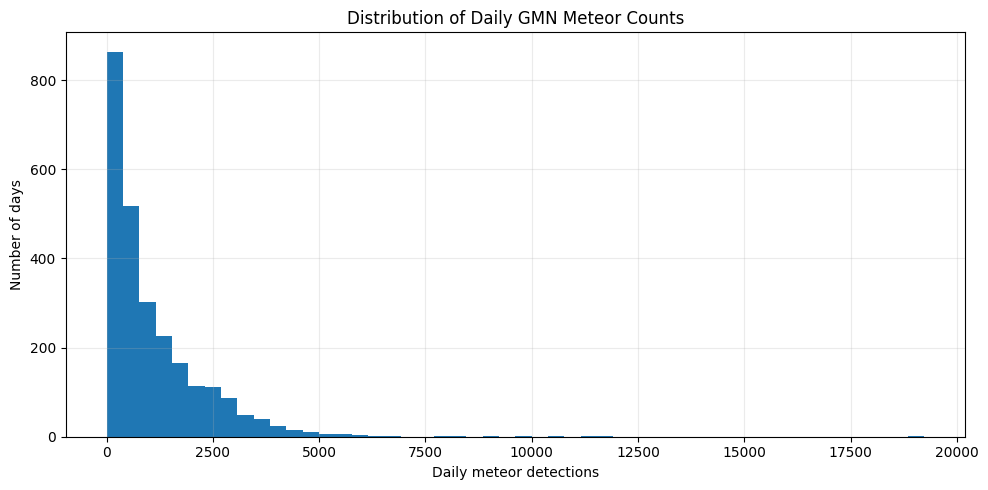

In [ ]:
# Cell 16: Quality control of the daily time series

print("Quality control of GMN daily meteor activity")
print("=" * 70)

# Check missing dates
full_index = pd.date_range(
    daily_activity.index.min(),
    daily_activity.index.max(),
    freq="1D"
)

missing_dates = full_index.difference(
    daily_activity.index
)

print(f"Expected number of days: {len(full_index):,}")
print(f"Actual number of days:   {len(daily_activity):,}")
print(f"Missing dates:           {len(missing_dates):,}")

# Reindex to make sure every day exists
daily_activity = daily_activity.reindex(
    full_index,
    fill_value=0
)

daily_activity.index.name = "date"

# Basic distribution
print("\nDaily total-count statistics:")
display(
    daily_activity["total_count"].describe()
)

print("\nHighest 10 daily detection counts:")
display(
    daily_activity[
        ["total_count", "shower_count", "non_shower_count"]
    ]
    .sort_values(
        "total_count",
        ascending=False
    )
    .head(10)
)

# Plot distribution
plt.figure(figsize=(10, 5))

plt.hist(
    daily_activity["total_count"],
    bins=50
)

plt.xlabel("Daily meteor detections")
plt.ylabel("Number of days")
plt.title("Distribution of Daily GMN Meteor Counts")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Calculating meteor activity background models...
Background models created:
  - 7-day median
  - 15-day median
  - 30-day median
  - 60-day median


,total_count,background_7d,background_15d,background_30d,background_60d
date,,,,,
2019-01-01,4,12.0,12.0,8.0,7.0
2019-01-02,6,18.0,18.0,7.5,7.0
2019-01-03,43,12.0,14.5,7.0,7.5
2019-01-04,18,18.0,11.0,6.5,8.0
2019-01-05,31,18.0,9.0,6.0,9.5
2019-01-06,0,31.0,8.0,5.5,11.0
2019-01-07,32,18.0,7.5,5.0,10.5
2019-01-08,0,11.0,8.0,4.5,11.0
2019-01-09,41,7.0,8.0,5.0,11.5


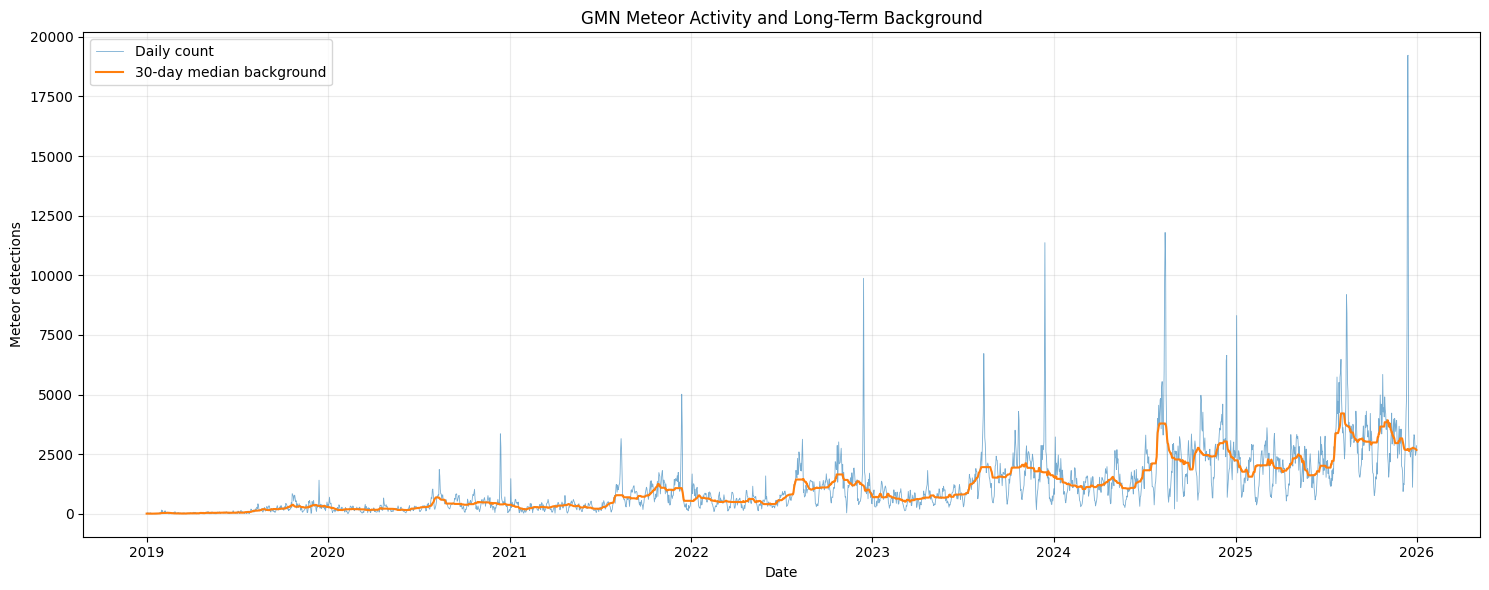

In [ ]:
# Cell 17: Estimate background activity at multiple time scales

print("Calculating meteor activity background models...")
print("=" * 70)

count_series = daily_activity["total_count"]

for window in [7, 15, 30, 60]:

    daily_activity[
        f"background_{window}d"
    ] = (
        count_series
        .rolling(
            window=window,
            center=True,
            min_periods=max(3, window // 2)
        )
        .median()
    )

print("Background models created:")
print("  - 7-day median")
print("  - 15-day median")
print("  - 30-day median")
print("  - 60-day median")

display(
    daily_activity[
        [
            "total_count",
            "background_7d",
            "background_15d",
            "background_30d",
            "background_60d"
        ]
    ].head(20)
)

# Plot a representative section of the long-term trend
plt.figure(figsize=(15, 6))

plt.plot(
    daily_activity.index,
    daily_activity["total_count"],
    linewidth=0.6,
    alpha=0.6,
    label="Daily count"
)

plt.plot(
    daily_activity.index,
    daily_activity["background_30d"],
    linewidth=1.5,
    label="30-day median background"
)

plt.xlabel("Date")
plt.ylabel("Meteor detections")
plt.title(
    "GMN Meteor Activity and Long-Term Background"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 18: Robust anomaly scores using Median Absolute Deviation

print("Calculating robust anomaly scores...")
print("=" * 70)

def robust_zscore(series, window):
    """
    Calculate a rolling robust Z-score using
    median and Median Absolute Deviation (MAD).
    """

    rolling_median = (
        series
        .rolling(
            window=window,
            center=True,
            min_periods=max(3, window // 2)
        )
        .median()
    )

    rolling_mad = (
        series
        .rolling(
            window=window,
            center=True,
            min_periods=max(3, window // 2)
        )
        .apply(
            lambda x: np.median(
                np.abs(x - np.median(x))
            ),
            raw=True
        )
    )

    robust_sigma = 1.4826 * rolling_mad

    score = (
        (series - rolling_median)
        / robust_sigma.replace(0, np.nan)
    )

    return score


# Calculate anomaly scores at multiple scales
for window in [7, 15, 30]:

    daily_activity[
        f"robust_z_{window}d"
    ] = robust_zscore(
        daily_activity["total_count"],
        window
    )

print("Robust Z-score columns created.")

display(
    daily_activity[
        [
            "total_count",
            "robust_z_7d",
            "robust_z_15d",
            "robust_z_30d"
        ]
    ].head(20)
)

Calculating robust anomaly scores...
Robust Z-score columns created.


,total_count,robust_z_7d,robust_z_15d,robust_z_30d
date,,,,
2019-01-01,4,-0.770847,-0.449661,-0.337245
2019-01-02,6,-0.622607,-0.578135,-0.134898
2019-01-03,43,2.090921,1.325723,3.468810
2019-01-04,18,0.000000,0.429221,1.193330
2019-01-05,31,0.626313,1.648755,2.810378
2019-01-06,0,-1.742434,-0.674491,-0.674491
2019-01-07,32,0.674491,2.203336,3.642250
2019-01-08,0,-0.674491,-0.674491,-0.674491
2019-01-09,41,3.276098,2.782274,4.856333


In [ ]:
# Cell 19: Identify candidate meteor activity enhancement days

print("Identifying candidate meteor activity enhancements...")
print("=" * 70)

for window in [7, 15, 30]:

    score_column = f"robust_z_{window}d"

    daily_activity[
        f"anomaly_{window}d"
    ] = daily_activity[
        score_column
    ] >= 3.0


# Use the 15-day model as the primary detection scale
daily_activity["candidate_anomaly"] = (
    daily_activity["robust_z_15d"] >= 3.0
)

daily_activity["strong_anomaly"] = (
    daily_activity["robust_z_15d"] >= 4.0
)

daily_activity["extreme_anomaly"] = (
    daily_activity["robust_z_15d"] >= 5.0
)


print("Candidate anomaly thresholds:")
print("  Z >= 3 : candidate enhancement")
print("  Z >= 4 : strong enhancement")
print("  Z >= 5 : extreme enhancement")

print()

print(
    "Candidate anomaly days:",
    int(daily_activity["candidate_anomaly"].sum())
)

print(
    "Strong anomaly days:",
    int(daily_activity["strong_anomaly"].sum())
)

print(
    "Extreme anomaly days:",
    int(daily_activity["extreme_anomaly"].sum())
)

print("\nTop candidate anomaly days:")

display(
    daily_activity[
        daily_activity["candidate_anomaly"]
    ][
        [
            "total_count",
            "shower_count",
            "non_shower_count",
            "robust_z_7d",
            "robust_z_15d",
            "robust_z_30d"
        ]
    ]
    .sort_values(
        "robust_z_15d",
        ascending=False
    )
    .head(30)
)

Identifying candidate meteor activity enhancements...
Candidate anomaly thresholds:
  Z >= 3 : candidate enhancement
  Z >= 4 : strong enhancement
  Z >= 5 : extreme enhancement

Candidate anomaly days: 49
Strong anomaly days: 25
Extreme anomaly days: 16

Top candidate anomaly days:


,total_count,shower_count,non_shower_count,robust_z_7d,robust_z_15d,robust_z_30d
date,,,,,,
2025-12-14,19224,15525,3699,4.278250,28.380363,16.907337
2020-12-13,3354,2589,765,5.251821,22.064376,19.573457
2020-12-14,2798,2181,617,4.139012,17.753837,15.896821
2025-01-03,8313,5065,3248,12.134720,17.142080,9.836391
2025-12-13,19192,15170,4022,4.510499,13.489815,14.965519
2019-12-14,1409,1142,267,9.830934,11.764888,11.262427
2022-12-14,9873,8512,1361,13.696050,11.620858,12.299371
2020-08-12,1857,1322,535,5.650242,9.478370,5.196398
2022-05-31,1588,1003,585,6.303894,8.532714,9.055805


In [ ]:
# Cell 20: Group consecutive anomaly days into activity-enhancement events

print("Grouping consecutive anomaly days...")
print("=" * 70)

anomaly_dates = daily_activity.index[
    daily_activity["candidate_anomaly"]
]

events = []

if len(anomaly_dates) > 0:

    event_start = anomaly_dates[0]
    previous_date = anomaly_dates[0]

    for current_date in anomaly_dates[1:]:

        gap = (
            current_date - previous_date
        ).days

        # Consecutive days belong to the same event
        if gap <= 1:
            previous_date = current_date

        else:

            events.append(
                (event_start, previous_date)
            )

            event_start = current_date
            previous_date = current_date

    # Add final event
    events.append(
        (event_start, previous_date)
    )


event_records = []

for event_id, (start, end) in enumerate(
    events,
    start=1
):

    event_data = daily_activity.loc[
        start:end
    ]

    peak_date = event_data[
        "total_count"
    ].idxmax()

    peak_count = event_data[
        "total_count"
    ].max()

    peak_z = event_data[
        "robust_z_15d"
    ].max()

    total_meteors = event_data[
        "total_count"
    ].sum()

    shower_meteors = event_data[
        "shower_count"
    ].sum()

    duration = (
        end - start
    ).days + 1

    event_records.append({
        "event_id": event_id,
        "start_date": start,
        "end_date": end,
        "duration_days": duration,
        "peak_date": peak_date,
        "peak_count": peak_count,
        "peak_robust_z": peak_z,
        "total_meteors": total_meteors,
        "shower_meteors": shower_meteors
    })


anomaly_events = pd.DataFrame(
    event_records
)

print(
    f"Number of candidate enhancement events: "
    f"{len(anomaly_events)}"
)

if len(anomaly_events) > 0:

    print("\nCandidate events:")
    display(
        anomaly_events.sort_values(
            "peak_robust_z",
            ascending=False
        ).head(30)
    )

Grouping consecutive anomaly days...
Number of candidate enhancement events: 30

Candidate events:


,event_id,start_date,end_date,duration_days,peak_date,peak_count,peak_robust_z,total_meteors,shower_meteors
29,30,2025-12-12,2025-12-14,3,2025-12-14,19224,28.380363,46377,35881
11,12,2020-12-12,2020-12-14,3,2020-12-13,3354,22.064376,7423,5628
27,28,2025-01-02,2025-01-03,2,2025-01-03,8313,17.142080,12047,5995
7,8,2019-12-14,2019-12-14,1,2019-12-14,1409,11.764888,1409,1142
18,19,2022-12-13,2022-12-15,3,2022-12-14,9873,11.620858,18472,14741
10,11,2020-08-12,2020-08-13,2,2020-08-12,1857,9.478370,3447,2441
17,18,2022-05-31,2022-05-31,1,2022-05-31,1588,8.532714,1588,1003
24,25,2023-12-13,2023-12-15,3,2023-12-14,11367,8.480004,23153,17804
12,13,2021-01-03,2021-01-03,1,2021-01-03,1472,6.716083,1472,1155
23,24,2023-10-14,2023-10-15,2,2023-10-15,3505,6.292289,6290,1796


In [ ]:
# Cell 21: Characterize candidate activity-enhancement events

print("Characterizing candidate activity-enhancement events")
print("=" * 70)

if len(anomaly_events) > 0:

    print("Event statistics:")
    display(
        anomaly_events[
            [
                "duration_days",
                "peak_count",
                "peak_robust_z",
                "total_meteors",
                "shower_meteors"
            ]
        ].describe()
    )

    # Add shower fraction
    anomaly_events["shower_fraction"] = (
        anomaly_events["shower_meteors"]
        / anomaly_events["total_meteors"]
    )

    print("\nEvents with the highest anomaly scores:")

    display(
        anomaly_events.sort_values(
            "peak_robust_z",
            ascending=False
        ).head(20)
    )

    print("\nEvents with the highest shower fractions:")

    display(
        anomaly_events.sort_values(
            "shower_fraction",
            ascending=False
        ).head(20)
    )

else:

    print(
        "No candidate anomaly events were detected."
    )

Characterizing candidate activity-enhancement events
Event statistics:


,duration_days,peak_count,peak_robust_z,total_meteors,shower_meteors
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1.633333,3692.966667,7.002623,6651.900000,4630.266667
std,0.718395,4690.289650,5.979842,10192.840836,7846.751974
min,1.000000,36.000000,3.007864,36.000000,1.000000
25%,1.000000,492.000000,3.544176,764.000000,153.750000
50%,1.500000,1440.500000,4.496679,1530.000000,873.000000
75%,2.000000,6235.500000,8.039024,8368.750000,5903.250000
max,3.000000,19224.000000,28.380363,46377.000000,35881.000000



Events with the highest anomaly scores:


,event_id,start_date,end_date,duration_days,peak_date,peak_count,peak_robust_z,total_meteors,shower_meteors,shower_fraction
29,30,2025-12-12,2025-12-14,3,2025-12-14,19224,28.380363,46377,35881,0.773681
11,12,2020-12-12,2020-12-14,3,2020-12-13,3354,22.064376,7423,5628,0.758184
27,28,2025-01-02,2025-01-03,2,2025-01-03,8313,17.142080,12047,5995,0.497634
7,8,2019-12-14,2019-12-14,1,2019-12-14,1409,11.764888,1409,1142,0.810504
18,19,2022-12-13,2022-12-15,3,2022-12-14,9873,11.620858,18472,14741,0.798019
10,11,2020-08-12,2020-08-13,2,2020-08-12,1857,9.478370,3447,2441,0.708152
17,18,2022-05-31,2022-05-31,1,2022-05-31,1588,8.532714,1588,1003,0.631612
24,25,2023-12-13,2023-12-15,3,2023-12-14,11367,8.480004,23153,17804,0.768972
12,13,2021-01-03,2021-01-03,1,2021-01-03,1472,6.716083,1472,1155,0.784647
23,24,2023-10-14,2023-10-15,2,2023-10-15,3505,6.292289,6290,1796,0.285533



Events with the highest shower fractions:


,event_id,start_date,end_date,duration_days,peak_date,peak_count,peak_robust_z,total_meteors,shower_meteors,shower_fraction
7,8,2019-12-14,2019-12-14,1,2019-12-14,1409,11.764888,1409,1142,0.810504
14,15,2021-12-13,2021-12-14,2,2021-12-13,5013,4.406820,8684,7038,0.810456
26,27,2024-12-14,2024-12-14,1,2024-12-14,6643,4.284382,6643,5361,0.807015
18,19,2022-12-13,2022-12-15,3,2022-12-14,9873,11.620858,18472,14741,0.798019
12,13,2021-01-03,2021-01-03,1,2021-01-03,1472,6.716083,1472,1155,0.784647
29,30,2025-12-12,2025-12-14,3,2025-12-14,19224,28.380363,46377,35881,0.773681
24,25,2023-12-13,2023-12-15,3,2023-12-14,11367,8.480004,23153,17804,0.768972
11,12,2020-12-12,2020-12-14,3,2020-12-13,3354,22.064376,7423,5628,0.758184
22,23,2023-08-13,2023-08-14,2,2023-08-13,6718,4.713446,11887,8711,0.732817
28,29,2025-08-12,2025-08-13,2,2025-08-12,9187,4.788536,17594,12688,0.721155


Generating main anomaly-detection figure...


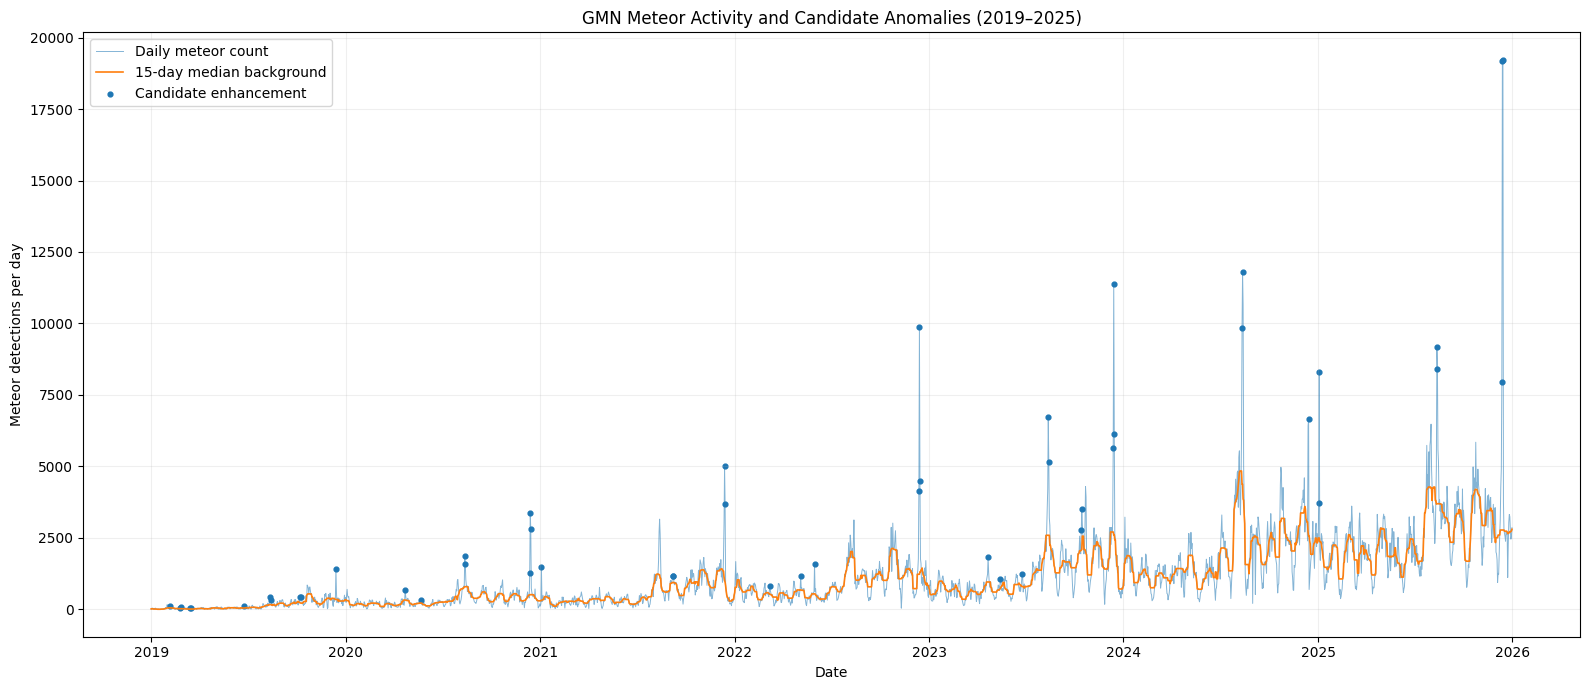

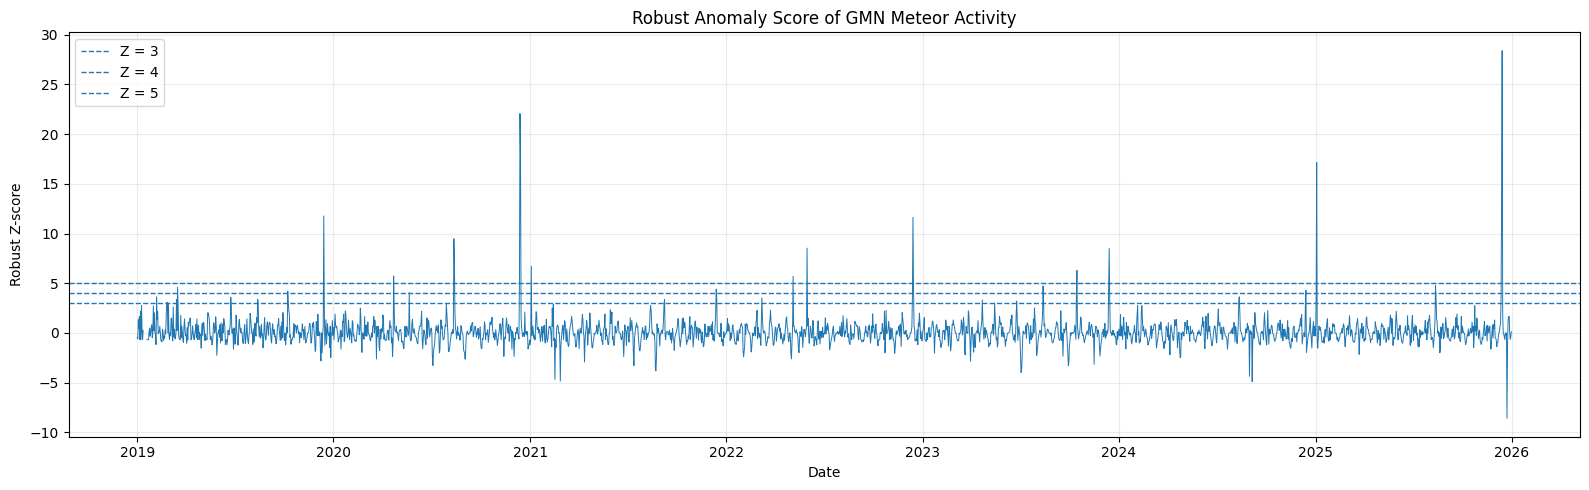

In [ ]:
# Cell 22: Visualize the complete anomaly-detection result

print("Generating main anomaly-detection figure...")
print("=" * 70)

fig, ax1 = plt.subplots(
    figsize=(16, 7)
)

# ---------------------------------------------------------
# Daily meteor activity
# ---------------------------------------------------------

ax1.plot(
    daily_activity.index,
    daily_activity["total_count"],
    linewidth=0.7,
    alpha=0.55,
    label="Daily meteor count"
)

# Background
ax1.plot(
    daily_activity.index,
    daily_activity["background_15d"],
    linewidth=1.2,
    label="15-day median background"
)

# Candidate anomaly days
candidate_mask = (
    daily_activity["candidate_anomaly"]
)

ax1.scatter(
    daily_activity.index[candidate_mask],
    daily_activity.loc[
        candidate_mask,
        "total_count"
    ],
    s=12,
    label="Candidate enhancement"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Meteor detections per day")

ax1.set_title(
    "GMN Meteor Activity and Candidate Anomalies (2019–2025)"
)

ax1.grid(alpha=0.2)

ax1.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Robust Z-score plot
# ---------------------------------------------------------

plt.figure(figsize=(16, 5))

plt.plot(
    daily_activity.index,
    daily_activity["robust_z_15d"],
    linewidth=0.7
)

plt.axhline(
    3,
    linestyle="--",
    linewidth=1,
    label="Z = 3"
)

plt.axhline(
    4,
    linestyle="--",
    linewidth=1,
    label="Z = 4"
)

plt.axhline(
    5,
    linestyle="--",
    linewidth=1,
    label="Z = 5"
)

plt.xlabel("Date")
plt.ylabel("Robust Z-score")

plt.title(
    "Robust Anomaly Score of GMN Meteor Activity"
)

plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cell 23: Detailed characterization of candidate enhancement events

print("Detailed characterization of candidate enhancement events")
print("=" * 75)

# ---------------------------------------------------------
# Add additional statistics to each event
# ---------------------------------------------------------

event_details = []

for _, event in anomaly_events.iterrows():

    start = event["start_date"]
    end = event["end_date"]

    event_data = daily_activity.loc[start:end].copy()

    peak_date = event_data["total_count"].idxmax()

    # Corresponding shower fraction on peak day
    peak_day_shower_fraction = (
        event_data.loc[
            peak_date,
            "shower_count"
        ]
        /
        event_data.loc[
            peak_date,
            "total_count"
        ]
        if event_data.loc[
            peak_date,
            "total_count"
        ] > 0
        else np.nan
    )

    event_details.append({
        "event_id": int(event["event_id"]),
        "start_date": start,
        "end_date": end,
        "duration_days": int(event["duration_days"]),
        "peak_date": peak_date,
        "peak_count": int(event["peak_count"]),
        "peak_robust_z": event["peak_robust_z"],
        "total_meteors": int(event["total_meteors"]),
        "shower_meteors": int(event["shower_meteors"]),
        "shower_fraction": (
            event["shower_meteors"]
            / event["total_meteors"]
        ),
        "peak_day_shower_fraction": (
            peak_day_shower_fraction
        )
    })

event_details = pd.DataFrame(
    event_details
)

event_details = event_details.sort_values(
    "peak_robust_z",
    ascending=False
).reset_index(drop=True)

print(
    f"Number of candidate events: "
    f"{len(event_details)}"
)

display(event_details)

Detailed characterization of candidate enhancement events
Number of candidate events: 30


,event_id,start_date,end_date,duration_days,peak_date,peak_count,peak_robust_z,total_meteors,shower_meteors,shower_fraction,peak_day_shower_fraction
0,30,2025-12-12,2025-12-14,3,2025-12-14,19224,28.380363,46377,35881,0.773681,0.807584
1,12,2020-12-12,2020-12-14,3,2020-12-13,3354,22.064376,7423,5628,0.758184,0.771914
2,28,2025-01-02,2025-01-03,2,2025-01-03,8313,17.142080,12047,5995,0.497634,0.609287
3,8,2019-12-14,2019-12-14,1,2019-12-14,1409,11.764888,1409,1142,0.810504,0.810504
4,19,2022-12-13,2022-12-15,3,2022-12-14,9873,11.620858,18472,14741,0.798019,0.862149
5,11,2020-08-12,2020-08-13,2,2020-08-12,1857,9.478370,3447,2441,0.708152,0.711901
6,18,2022-05-31,2022-05-31,1,2022-05-31,1588,8.532714,1588,1003,0.631612,0.631612
7,25,2023-12-13,2023-12-15,3,2023-12-14,11367,8.480004,23153,17804,0.768972,0.824844
8,13,2021-01-03,2021-01-03,1,2021-01-03,1472,6.716083,1472,1155,0.784647,0.784647
9,24,2023-10-14,2023-10-15,2,2023-10-15,3505,6.292289,6290,1796,0.285533,0.304422


In [ ]:
# Cell 24: Identify dominant meteor-shower codes for each anomaly event

print("Identifying dominant shower codes...")
print("=" * 75)

# ---------------------------------------------------------
# Count shower codes during each candidate event
# ---------------------------------------------------------

dominant_shower_records = []

for _, event in event_details.iterrows():

    start = event["start_date"]
    end = event["end_date"]

    event_data = gmn_analysis[
        (gmn_analysis["UTC Time"] >= start) &
        (gmn_analysis["UTC Time"] < end + pd.Timedelta(days=1))
    ].copy()

    # Keep only assigned shower codes
    shower_data = event_data[
        event_data["is_shower_associated"]
    ]

    if len(shower_data) == 0:
        dominant_shower_records.append({
            "event_id": int(event["event_id"]),
            "dominant_code": None,
            "dominant_count": 0,
            "all_shower_codes": ""
        })
        continue

    code_counts = (
        shower_data["code_clean"]
        .value_counts()
    )

    dominant_code = code_counts.index[0]
    dominant_count = int(code_counts.iloc[0])

    # Keep the top five codes
    top_codes = [
        f"{code} ({count})"
        for code, count
        in code_counts.head(5).items()
    ]

    dominant_shower_records.append({
        "event_id": int(event["event_id"]),
        "dominant_code": dominant_code,
        "dominant_count": dominant_count,
        "all_shower_codes": ", ".join(top_codes)
    })

dominant_shower_df = pd.DataFrame(
    dominant_shower_records
)

event_details = event_details.merge(
    dominant_shower_df,
    on="event_id",
    how="left"
)

print("Dominant shower codes identified.")

display(
    event_details[
        [
            "event_id",
            "start_date",
            "end_date",
            "peak_date",
            "peak_count",
            "peak_robust_z",
            "shower_fraction",
            "dominant_code",
            "dominant_count",
            "all_shower_codes"
        ]
    ]
)

Identifying dominant shower codes...
Dominant shower codes identified.


,event_id,start_date,end_date,peak_date,peak_count,peak_robust_z,shower_fraction,dominant_code,dominant_count,all_shower_codes
0,30,2025-12-12,2025-12-14,2025-12-14,19224,28.380363,0.773681,GEM,32428,"GEM (32428), MON (561), HYD (482), THA (333), ..."
1,12,2020-12-12,2020-12-14,2020-12-13,3354,22.064376,0.758184,GEM,5199,"GEM (5199), HYD (70), THA (64), MON (61), COM ..."
2,28,2025-01-02,2025-01-03,2025-01-03,8313,17.142080,0.497634,QUA,5121,"QUA (5121), COM (183), AHY (113), NCC (60), SC..."
3,8,2019-12-14,2019-12-14,2019-12-14,1409,11.764888,0.810504,GEM,1092,"GEM (1092), MON (13), THA (6), HYD (5), COM (4)"
4,19,2022-12-13,2022-12-15,2022-12-14,9873,11.620858,0.798019,GEM,13589,"GEM (13589), COM (225), HYD (166), MON (156), ..."
5,11,2020-08-12,2020-08-13,2020-08-12,1857,9.478370,0.708152,PER,2292,"PER (2292), NDA (28), AOA (20), ERI (13), AUD ..."
6,18,2022-05-31,2022-05-31,2022-05-31,1588,8.532714,0.631612,TAH,975,"TAH (975), JMC (11), MPS (6), JMP (5), ETA (2)"
7,25,2023-12-13,2023-12-15,2023-12-14,11367,8.480004,0.768972,GEM,16136,"GEM (16136), HYD (246), MON (243), COM (193), ..."
8,13,2021-01-03,2021-01-03,2021-01-03,1472,6.716083,0.784647,QUA,1112,"QUA (1112), COM (11), DSV (7), NCC (3), AHY (3)"
9,24,2023-10-14,2023-10-15,2023-10-15,3505,6.292289,0.285533,STA,487,"STA (487), ORI (460), SOA (123), OCU (102), NU..."


Global distribution of GMN meteor-shower codes
Total unique shower codes: 421

Top 30 shower codes:


,meteor_count
code_clean,
PER,123852
GEM,104655
ORI,52467
SDA,34148
ETA,25198
STA,19619
HYD,14200
CAP,12721
QUA,12210


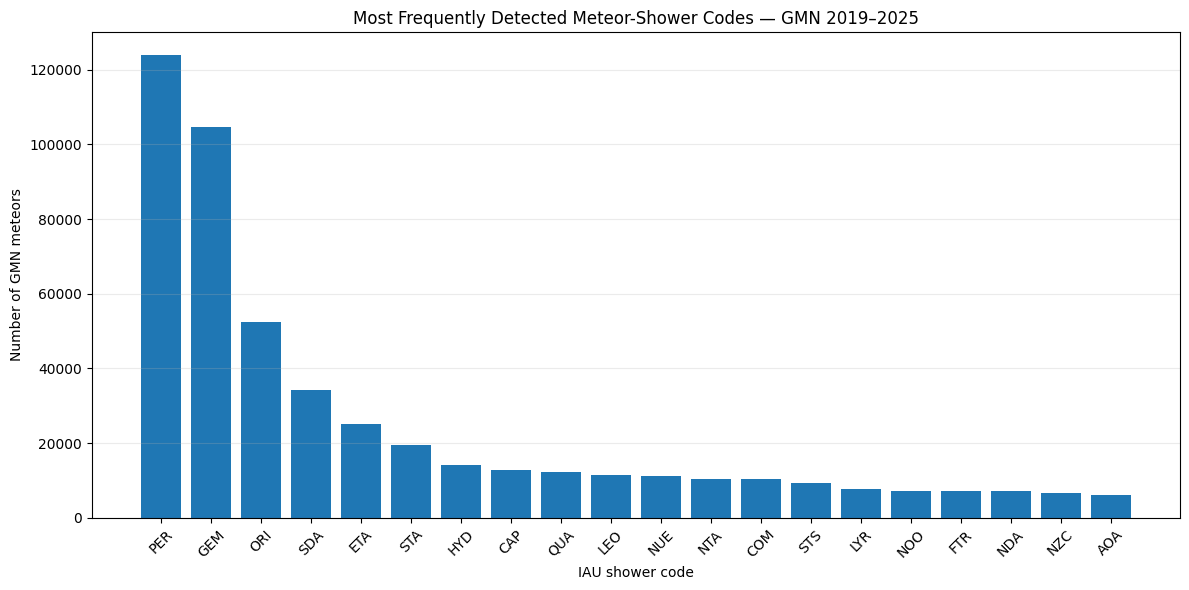

In [ ]:
# Cell 25: Global distribution of meteor-shower codes

print("Global distribution of GMN meteor-shower codes")
print("=" * 75)

shower_code_counts = (
    gmn_analysis[
        gmn_analysis["is_shower_associated"]
    ]["code_clean"]
    .value_counts()
)

print(
    f"Total unique shower codes: "
    f"{len(shower_code_counts)}"
)

print("\nTop 30 shower codes:")
display(
    shower_code_counts
    .head(30)
    .to_frame("meteor_count")
)

# ---------------------------------------------------------
# Plot top 20 shower codes
# ---------------------------------------------------------

top20 = shower_code_counts.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top20.index,
    top20.values
)

plt.xlabel("IAU shower code")
plt.ylabel("Number of GMN meteors")
plt.title(
    "Most Frequently Detected Meteor-Shower Codes — GMN 2019–2025"
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 26: Solar-longitude characteristics of candidate events

print("Analyzing solar longitude of candidate enhancement events")
print("=" * 75)

solar_longitude_records = []

for _, event in event_details.iterrows():

    start = event["start_date"]
    end = event["end_date"]

    event_data = gmn_analysis[
        (gmn_analysis["UTC Time"] >= start) &
        (gmn_analysis["UTC Time"] < end + pd.Timedelta(days=1))
    ].copy()

    # Remove invalid solar-longitude values
    event_data = event_data[
        event_data["Sol lon"].notna()
    ]

    if len(event_data) == 0:
        mean_sol_lon = np.nan
        median_sol_lon = np.nan
        min_sol_lon = np.nan
        max_sol_lon = np.nan

    else:
        mean_sol_lon = event_data["Sol lon"].mean()
        median_sol_lon = event_data["Sol lon"].median()
        min_sol_lon = event_data["Sol lon"].min()
        max_sol_lon = event_data["Sol lon"].max()

    solar_longitude_records.append({
        "event_id": int(event["event_id"]),
        "mean_sol_lon": mean_sol_lon,
        "median_sol_lon": median_sol_lon,
        "min_sol_lon": min_sol_lon,
        "max_sol_lon": max_sol_lon
    })

solar_longitude_df = pd.DataFrame(
    solar_longitude_records
)

event_details = event_details.merge(
    solar_longitude_df,
    on="event_id",
    how="left"
)

print("Solar-longitude statistics added.")

display(
    event_details[
        [
            "event_id",
            "peak_date",
            "dominant_code",
            "peak_robust_z",
            "mean_sol_lon",
            "median_sol_lon",
            "min_sol_lon",
            "max_sol_lon"
        ]
    ]
)

Analyzing solar longitude of candidate enhancement events
Solar-longitude statistics added.


,event_id,peak_date,dominant_code,peak_robust_z,mean_sol_lon,median_sol_lon,min_sol_lon,max_sol_lon
0,30,2025-12-14,GEM,28.380363,261.572065,261.781066,259.844210,262.894704
1,12,2020-12-13,GEM,22.064376,261.773480,261.954849,260.131448,263.182565
2,28,2025-01-03,QUA,17.142080,282.627301,282.703168,281.490083,283.528490
3,8,2019-12-14,GEM,11.764888,262.013600,262.130704,261.426348,262.423015
4,19,2022-12-14,GEM,11.620858,262.090867,262.071011,260.622811,263.672975
5,11,2020-08-12,PER,9.478370,140.349528,140.389987,139.472161,141.391784
6,18,2022-05-31,TAH,8.532714,69.541378,69.479765,69.249150,70.207271
7,25,2023-12-14,GEM,8.480004,261.838193,261.768812,260.367056,263.418221
8,13,2021-01-03,QUA,6.716083,282.983512,283.006468,282.544817,283.550046
9,24,2023-10-15,STA,6.292289,201.065434,201.118561,200.062518,202.044091


Plotting candidate anomalies by solar longitude...


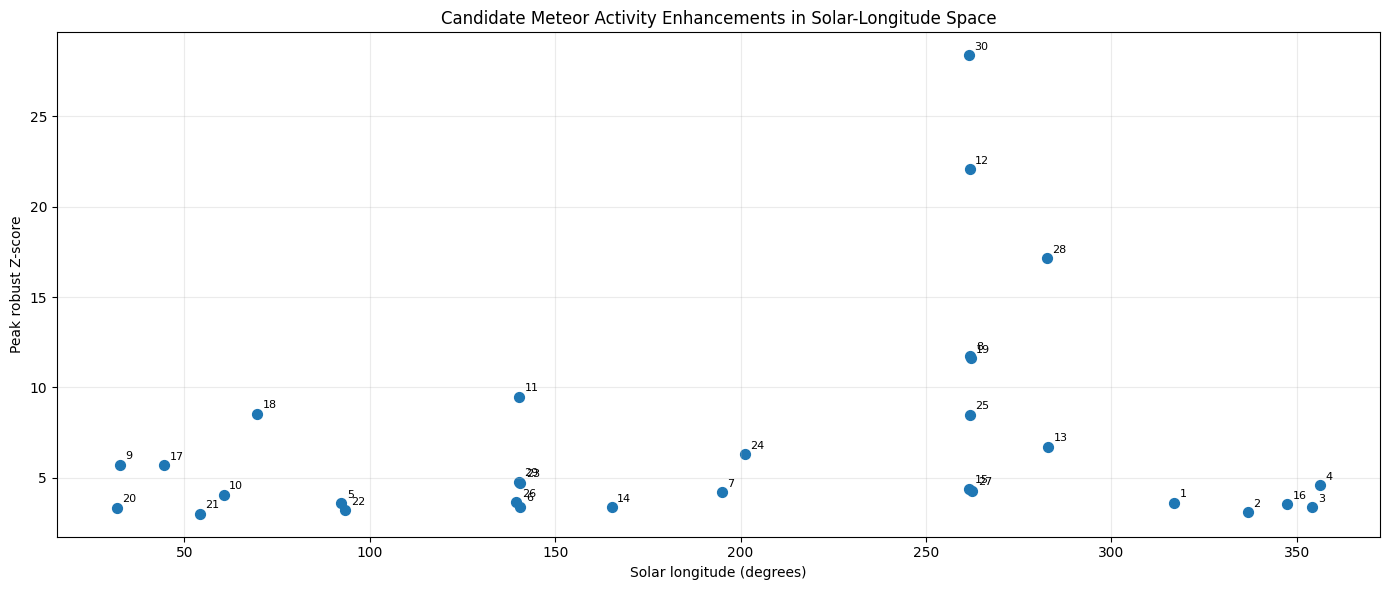

In [ ]:
# Cell 27: Candidate anomalies in solar-longitude space

print("Plotting candidate anomalies by solar longitude...")
print("=" * 75)

valid_events = event_details[
    event_details["mean_sol_lon"].notna()
].copy()

plt.figure(figsize=(14, 6))

plt.scatter(
    valid_events["mean_sol_lon"],
    valid_events["peak_robust_z"],
    s=50
)

for _, row in valid_events.iterrows():

    plt.annotate(
        str(int(row["event_id"])),
        (
            row["mean_sol_lon"],
            row["peak_robust_z"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Solar longitude (degrees)")
plt.ylabel("Peak robust Z-score")

plt.title(
    "Candidate Meteor Activity Enhancements "
    "in Solar-Longitude Space"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Examining long-term changes in GMN detection rate
Yearly GMN activity summary:


,mean_daily_count,median_daily_count,max_daily_count,total_meteors,candidate_anomaly_days
year,,,,,
2019,137.706849,67.0,1409,50263,11
2020,341.795082,266.5,3354,125097,7
2021,580.413699,413.0,5013,211851,5
2022,916.876712,724.0,9873,334660,6
2023,1238.090411,909.0,11367,451903,10
2024,1928.863388,1565.0,11794,705964,3
2025,2646.747945,2397.0,19224,966063,7


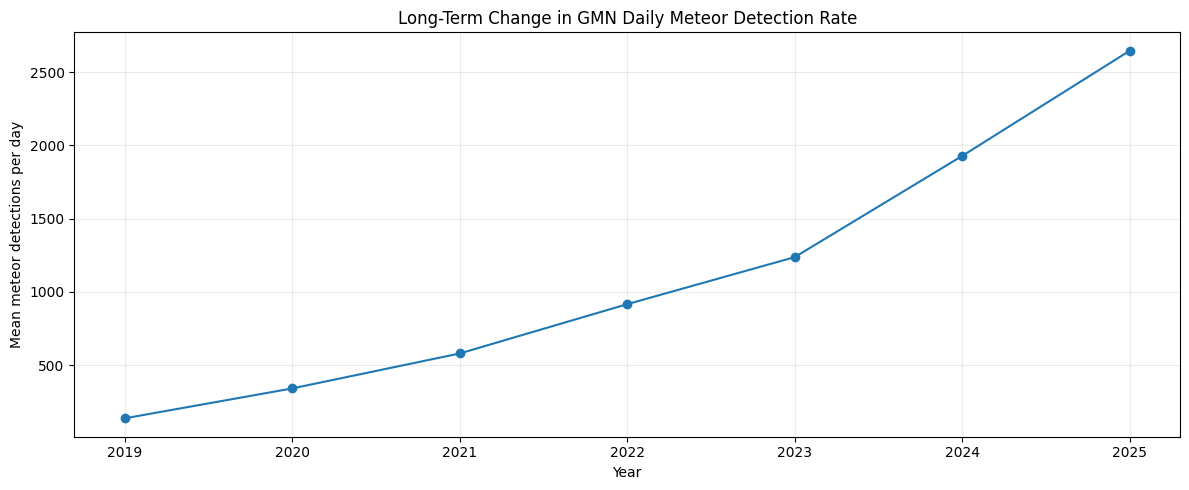


Annual-normalized activity preview:


,total_count,annual_normalized_count,candidate_anomaly
date,,,
2019-01-01,4,0.029047,False
2019-01-02,6,0.043571,False
2019-01-03,43,0.312258,False
2019-01-04,18,0.130712,False
2019-01-05,31,0.225116,False
2019-01-06,0,0.000000,False
2019-01-07,32,0.232378,False
2019-01-08,0,0.000000,False
2019-01-09,41,0.297734,False


In [ ]:
# Cell 28: Examine long-term observational-rate changes

print("Examining long-term changes in GMN detection rate")
print("=" * 75)

daily_activity["year"] = daily_activity.index.year

yearly_summary = (
    daily_activity
    .groupby("year")
    .agg(
        mean_daily_count=("total_count", "mean"),
        median_daily_count=("total_count", "median"),
        max_daily_count=("total_count", "max"),
        total_meteors=("total_count", "sum"),
        candidate_anomaly_days=("candidate_anomaly", "sum")
    )
)

print("Yearly GMN activity summary:")
display(yearly_summary)

# ---------------------------------------------------------
# Plot annual mean detection rate
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_summary.index,
    yearly_summary["mean_daily_count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean meteor detections per day")

plt.title(
    "Long-Term Change in GMN Daily Meteor Detection Rate"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Standardized daily activity
# ---------------------------------------------------------

year_mean = (
    daily_activity
    .groupby("year")["total_count"]
    .transform("mean")
)

daily_activity["annual_normalized_count"] = (
    daily_activity["total_count"]
    / year_mean
)

print("\nAnnual-normalized activity preview:")

display(
    daily_activity[
        [
            "total_count",
            "annual_normalized_count",
            "candidate_anomaly"
        ]
    ].head(20)
)

CELL 29: Observation-Rate Normalization

Existing daily_activity columns:
['total_count', 'shower_count', 'non_shower_count', 'background_7d', 'background_15d', 'background_30d', 'background_60d', 'robust_z_7d', 'robust_z_15d', 'robust_z_30d', 'anomaly_7d', 'anomaly_15d', 'anomaly_30d', 'candidate_anomaly', 'strong_anomaly', 'extreme_anomaly', 'year', 'annual_normalized_count']

Using existing daily count column: 'total_count'

Daily activity range:
Start: 2019-01-01
End:   2025-12-31
Total daily observations: 2,557

----------------------------------------------------------------------
YEARLY OBSERVATION-RATE ESTIMATE
----------------------------------------------------------------------


,median_daily_count,relative_observation_rate
year,,
2019,67.0,0.093
2020,266.5,0.368
2021,413.0,0.570
2022,724.0,1.000
2023,909.0,1.256
2024,1565.0,2.162
2025,2397.0,3.311



----------------------------------------------------------------------
NORMALIZED ANOMALY STATISTICS
----------------------------------------------------------------------
Candidate days (Z >= 3): 48
Strong days   (Z >= 4): 25
Extreme days  (Z >= 5): 16

----------------------------------------------------------------------
RAW VS NORMALIZED DETECTION
----------------------------------------------------------------------
Raw anomaly days: 55
Normalized anomaly days: 48
Common anomaly days: 19
Raw-only anomaly days: 36
Normalized-only anomaly days: 29


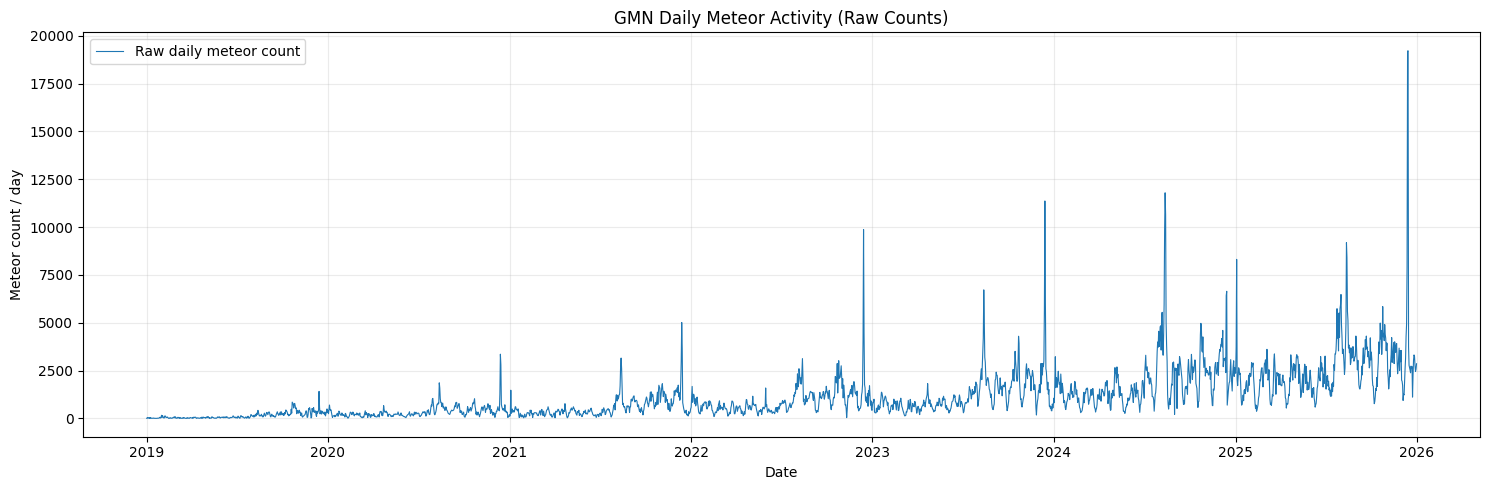

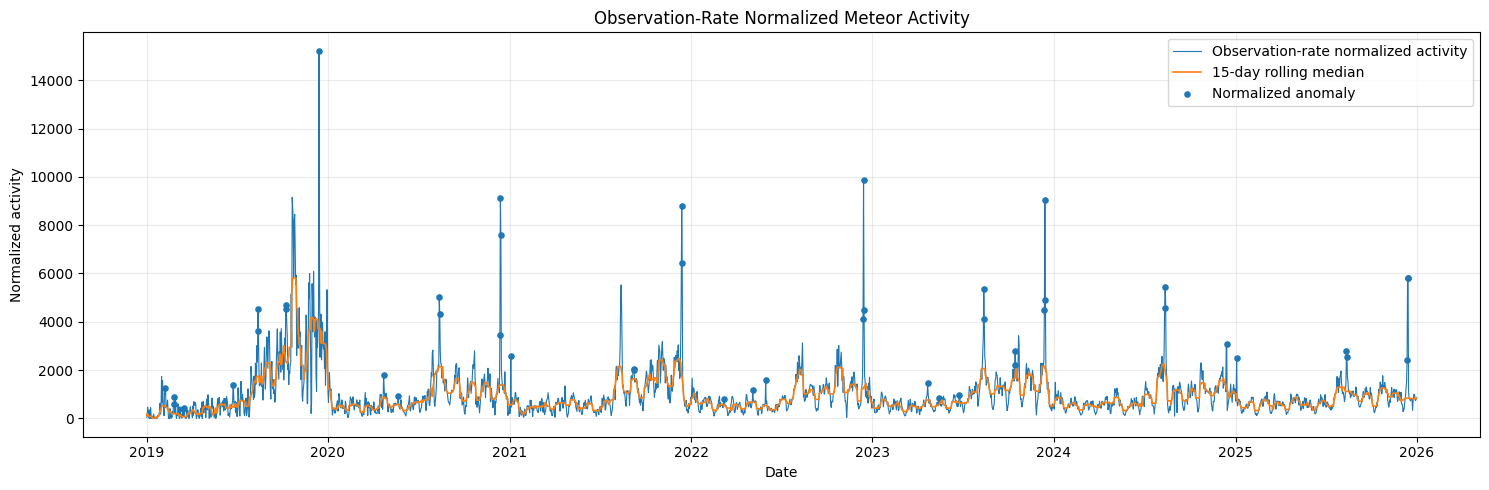


CELL 29 COMPLETED SUCCESSFULLY
Normalized dataset: 2,557 days


In [ ]:
# ============================================================
# CELL 29
# Observation-rate normalization + normalized anomaly detection
# Robust version compatible with previous notebook cells
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 29: Observation-Rate Normalization")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load daily activity data
# ------------------------------------------------------------

df = daily_activity.copy()

# Make sure index is datetime
df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nExisting daily_activity columns:")
print(list(df.columns))

# ------------------------------------------------------------
# 2. Automatically identify the daily total-count column
# ------------------------------------------------------------

possible_total_columns = [
    "daily_total",
    "total_meteors",
    "meteor_count",
    "daily_count",
    "total_count",
    "count",
    "n_meteors",
    "N_total"
]

total_col = None

for col in possible_total_columns:
    if col in df.columns:
        total_col = col
        break

# ------------------------------------------------------------
# 3. If no suitable column exists, reconstruct daily counts
#    directly from gmn_analysis
# ------------------------------------------------------------

if total_col is None:

    print("\nNo standard daily-count column found.")
    print("Reconstructing daily meteor counts from gmn_analysis...")

    gmn_tmp = gmn_analysis.copy()

    # Find datetime column
    datetime_col = None

    for col in [
        "UTC Time",
        "datetime",
        "date",
        "timestamp",
        "Datetime",
        "Date"
    ]:
        if col in gmn_tmp.columns:
            datetime_col = col
            break

    if datetime_col is not None:

        gmn_tmp["_datetime"] = pd.to_datetime(
            gmn_tmp[datetime_col],
            errors="coerce"
        )

    else:

        # Try the index
        gmn_tmp["_datetime"] = pd.to_datetime(
            gmn_tmp.index,
            errors="coerce"
        )

    # Remove invalid timestamps
    gmn_tmp = gmn_tmp[
        gmn_tmp["_datetime"].notna()
    ].copy()

    # Daily counts
    reconstructed = (
        gmn_tmp
        .set_index("_datetime")
        .resample("1D")
        .size()
        .rename("daily_total")
    )

    # Align with full daily time range
    full_index = pd.date_range(
        start=reconstructed.index.min(),
        end=reconstructed.index.max(),
        freq="1D"
    )

    reconstructed = reconstructed.reindex(
        full_index,
        fill_value=0
    )

    df = pd.DataFrame(
        index=full_index
    )

    df["daily_total"] = reconstructed.values

    total_col = "daily_total"

    print(
        f"Reconstructed {len(df):,} daily observations."
    )

else:

    print(
        f"\nUsing existing daily count column: '{total_col}'"
    )

    # Standardize the name so later code is independent
    df["daily_total"] = pd.to_numeric(
        df[total_col],
        errors="coerce"
    ).fillna(0)

# ------------------------------------------------------------
# 4. Basic data check
# ------------------------------------------------------------

df["daily_total"] = pd.to_numeric(
    df["daily_total"],
    errors="coerce"
).fillna(0)

df["year"] = df.index.year

print("\nDaily activity range:")
print(f"Start: {df.index.min().date()}")
print(f"End:   {df.index.max().date()}")

print(
    f"Total daily observations: {len(df):,}"
)

# ------------------------------------------------------------
# 5. Estimate yearly observation-rate differences
# ------------------------------------------------------------
#
# GMN observation coverage increased strongly over the study period.
# We therefore calculate a relative observation-rate factor for each
# year.
#
# IMPORTANT:
# This is NOT a physical meteor-flux calibration.
# It only reduces the influence of long-term network growth.

yearly_median = (
    df.groupby("year")["daily_total"]
    .median()
)

reference_level = yearly_median.median()

# Avoid division by zero
if reference_level <= 0:
    raise ValueError(
        "Reference observation level is zero. "
        "Cannot perform normalization."
    )

yearly_rate_table = pd.DataFrame({
    "median_daily_count": yearly_median,
    "relative_observation_rate":
        yearly_median / reference_level
})

df["observation_rate_factor"] = (
    df["year"]
    .map(yearly_rate_table["relative_observation_rate"])
)

# ------------------------------------------------------------
# 6. Observation-rate normalized activity
# ------------------------------------------------------------

df["normalized_total"] = (
    df["daily_total"]
    / df["observation_rate_factor"]
)

# ------------------------------------------------------------
# 7. Robust background estimation
# ------------------------------------------------------------

ROLLING_NORM = 15

df["norm_background"] = (
    df["normalized_total"]
    .rolling(
        ROLLING_NORM,
        center=True,
        min_periods=7
    )
    .median()
)

# ------------------------------------------------------------
# 8. Rolling MAD
# ------------------------------------------------------------

rolling_mad = (
    df["normalized_total"]
    .rolling(
        ROLLING_NORM,
        center=True,
        min_periods=7
    )
    .apply(
        lambda x: np.median(
            np.abs(
                x - np.median(x)
            )
        ),
        raw=True
    )
)

# ------------------------------------------------------------
# 9. Normalized robust Z-score
# ------------------------------------------------------------

denominator = (
    1.4826 *
    rolling_mad
)

denominator = denominator.replace(
    0,
    np.nan
)

df["norm_robust_z"] = (
    (
        df["normalized_total"]
        - df["norm_background"]
    )
    / denominator
)

# ------------------------------------------------------------
# 10. Normalized anomaly classification
# ------------------------------------------------------------

df["norm_candidate"] = (
    df["norm_robust_z"] >= 3
)

df["norm_strong"] = (
    df["norm_robust_z"] >= 4
)

df["norm_extreme"] = (
    df["norm_robust_z"] >= 5
)

# ------------------------------------------------------------
# 11. Recalculate raw robust Z-score for comparison
# ------------------------------------------------------------

raw_background = (
    df["daily_total"]
    .rolling(
        7,
        center=True,
        min_periods=3
    )
    .median()
)

raw_mad = (
    df["daily_total"]
    .rolling(
        7,
        center=True,
        min_periods=3
    )
    .apply(
        lambda x: np.median(
            np.abs(
                x - np.median(x)
            )
        ),
        raw=True
    )
)

raw_denominator = (
    1.4826 * raw_mad
).replace(
    0,
    np.nan
)

df["raw_robust_z_recalc"] = (
    (
        df["daily_total"]
        - raw_background
    )
    / raw_denominator
)

df["raw_candidate"] = (
    df["raw_robust_z_recalc"] >= 3
)

# ------------------------------------------------------------
# 12. Print yearly observation-rate table
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("YEARLY OBSERVATION-RATE ESTIMATE")
print("-" * 70)

display(
    yearly_rate_table.round(3)
)

# ------------------------------------------------------------
# 13. Print normalized anomaly statistics
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("NORMALIZED ANOMALY STATISTICS")
print("-" * 70)

print(
    f"Candidate days (Z >= 3): "
    f"{int(df['norm_candidate'].sum())}"
)

print(
    f"Strong days   (Z >= 4): "
    f"{int(df['norm_strong'].sum())}"
)

print(
    f"Extreme days  (Z >= 5): "
    f"{int(df['norm_extreme'].sum())}"
)

# ------------------------------------------------------------
# 14. Raw vs normalized comparison
# ------------------------------------------------------------

raw_days = set(
    df.index[df["raw_candidate"]]
)

norm_days = set(
    df.index[df["norm_candidate"]]
)

common_days = raw_days & norm_days
raw_only_days = raw_days - norm_days
norm_only_days = norm_days - raw_days

print("\n" + "-" * 70)
print("RAW VS NORMALIZED DETECTION")
print("-" * 70)

print(
    f"Raw anomaly days: "
    f"{len(raw_days)}"
)

print(
    f"Normalized anomaly days: "
    f"{len(norm_days)}"
)

print(
    f"Common anomaly days: "
    f"{len(common_days)}"
)

print(
    f"Raw-only anomaly days: "
    f"{len(raw_only_days)}"
)

print(
    f"Normalized-only anomaly days: "
    f"{len(norm_only_days)}"
)

# ------------------------------------------------------------
# 15. Plot raw activity
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 5)
)

ax.plot(
    df.index,
    df["daily_total"],
    linewidth=0.8,
    label="Raw daily meteor count"
)

ax.set_xlabel("Date")
ax.set_ylabel("Meteor count / day")
ax.set_title(
    "GMN Daily Meteor Activity (Raw Counts)"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 16. Plot normalized activity + anomalies
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 5)
)

ax.plot(
    df.index,
    df["normalized_total"],
    linewidth=0.8,
    label="Observation-rate normalized activity"
)

ax.plot(
    df.index,
    df["norm_background"],
    linewidth=1.2,
    label="15-day rolling median"
)

# Candidate anomalies
anomaly_mask = df["norm_candidate"]

ax.scatter(
    df.index[anomaly_mask],
    df.loc[
        anomaly_mask,
        "normalized_total"
    ],
    s=14,
    label="Normalized anomaly"
)

ax.set_xlabel("Date")
ax.set_ylabel("Normalized activity")
ax.set_title(
    "Observation-Rate Normalized Meteor Activity"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 17. Save normalized dataset for Cell 30/31
# ------------------------------------------------------------

daily_normalized = df.copy()

print("\n" + "=" * 70)
print("CELL 29 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"Normalized dataset: "
    f"{len(daily_normalized):,} days"
)

In [ ]:
# ============================================================
# CELL 30: Known Meteor Shower Validation
# ============================================================

print("=" * 70)
print("CELL 30: Known Meteor Shower Validation")
print("=" * 70)

# ------------------------------------------------------------
# 1. Use original GMN data
# ------------------------------------------------------------
g = gmn_data.copy()

print("\nGMN columns:")
print(list(g.columns))

# Actual GMN column names confirmed from the dataset
time_col = "UTC Time"
code_col = "code"
sol_col = "Sol lon"

# ------------------------------------------------------------
# 2. Prepare columns
# ------------------------------------------------------------
g["_date"] = pd.to_datetime(
    g[time_col],
    errors="coerce"
).dt.normalize()

g["_sol"] = pd.to_numeric(
    g[sol_col],
    errors="coerce"
)

g["_code"] = (
    g[code_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Remove invalid codes
invalid_codes = {
    "",
    "NAN",
    "NONE",
    "NULL",
    "NA",
    "-1",
    "0",
    "...",
    "N/A"
}

g.loc[g["_code"].isin(invalid_codes), "_code"] = np.nan


# ------------------------------------------------------------
# 3. Major established annual meteor showers
#    Solar-longitude centers used for validation
# ------------------------------------------------------------
shower_reference = {
    "QUA": ("Quadrantids", 282.5),
    "LYR": ("April Lyrids", 32.1),
    "ETA": ("eta Aquariids", 45.5),
    "SDA": ("Southern delta-Aquariids", 125.5),
    "PER": ("Perseids", 140.0),
    "ORI": ("Orionids", 208.0),
    "STA": ("Southern Taurids", 220.0),
    "NTA": ("Northern Taurids", 230.0),
    "LEO": ("Leonids", 235.0),
    "GEM": ("Geminids", 262.0),
    "URS": ("Ursids", 270.7)
}


# ------------------------------------------------------------
# 4. Candidate events
# ------------------------------------------------------------
events = event_details.copy()

events["peak_date"] = pd.to_datetime(
    events["peak_date"],
    errors="coerce"
).dt.normalize()

results = []


# ------------------------------------------------------------
# 5. Validate each event
# ------------------------------------------------------------
for _, event in events.iterrows():

    event_id = event.get("event_id", np.nan)
    peak_date = event["peak_date"]

    if pd.isna(peak_date):
        continue

    # Use ±1 day around the event peak
    start_date = peak_date - pd.Timedelta(days=1)
    end_date = peak_date + pd.Timedelta(days=1)

    window = g[
        (g["_date"] >= start_date) &
        (g["_date"] <= end_date)
    ].copy()

    # --------------------------------------------------------
    # Dominant meteor-shower code
    # --------------------------------------------------------
    valid_codes = window["_code"].dropna()

    if len(valid_codes) > 0:

        code_counts = valid_codes.value_counts()

        dominant_code = code_counts.index[0]
        dominant_code_count = int(code_counts.iloc[0])

    else:

        dominant_code = np.nan
        dominant_code_count = 0


    # --------------------------------------------------------
    # Mean solar longitude
    # --------------------------------------------------------
    sol_values = window["_sol"].dropna()

    if len(sol_values) > 0:
        mean_sol = float(sol_values.mean())
    else:
        mean_sol = np.nan


    # --------------------------------------------------------
    # Match with known shower
    # --------------------------------------------------------
    if dominant_code in shower_reference:

        shower_name, reference_sol = shower_reference[dominant_code]

        if pd.notna(mean_sol):

            # Circular distance on 0–360° scale
            distance = abs(mean_sol - reference_sol)
            distance = min(distance, 360.0 - distance)

        else:
            distance = np.nan

        # Within 5° of expected solar longitude
        matched = (
            pd.notna(distance) and
            distance <= 5.0
        )

    else:

        shower_name = np.nan
        reference_sol = np.nan
        distance = np.nan
        matched = False


    # --------------------------------------------------------
    # Event statistics
    # --------------------------------------------------------
    peak_count = event.get("peak_count", np.nan)
    peak_z = event.get("peak_robust_z", np.nan)
    total_meteors = event.get("total_meteors", np.nan)
    shower_meteors = event.get("shower_meteors", np.nan)

    if pd.notna(total_meteors) and total_meteors > 0:
        shower_fraction = shower_meteors / total_meteors
    else:
        shower_fraction = np.nan


    results.append({
        "event_id": event_id,
        "peak_date": peak_date,
        "dominant_code": dominant_code,
        "matched_shower": shower_name,
        "reference_solar_longitude": reference_sol,
        "mean_solar_longitude": mean_sol,
        "solar_longitude_distance": distance,
        "dominant_code_count": dominant_code_count,
        "peak_count": peak_count,
        "peak_robust_z": peak_z,
        "total_meteors": total_meteors,
        "shower_meteors": shower_meteors,
        "shower_fraction": shower_fraction,
        "known_shower_match": matched
    })


# ------------------------------------------------------------
# 6. Final validation dataframe
# ------------------------------------------------------------
event_validation_final = pd.DataFrame(results)

if len(event_validation_final) > 0:

    event_validation_final = (
        event_validation_final
        .sort_values("peak_robust_z", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("KNOWN SHOWER VALIDATION RESULTS")
print("=" * 70)

display(
    event_validation_final[
        [
            "event_id",
            "peak_date",
            "dominant_code",
            "matched_shower",
            "mean_solar_longitude",
            "solar_longitude_distance",
            "peak_robust_z",
            "shower_fraction",
            "known_shower_match"
        ]
    ]
)


# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------
total_events = len(event_validation_final)

matched_events = int(
    event_validation_final["known_shower_match"].sum()
) if total_events > 0 else 0

association_rate = (
    matched_events / total_events
    if total_events > 0
    else np.nan
)

print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

print(f"Total candidate events       : {total_events}")
print(f"Known-shower associated      : {matched_events}")
print(f"Association rate             : {association_rate:.1%}")


if matched_events > 0:

    print("\nMatched showers:")

    display(
        event_validation_final.loc[
            event_validation_final["known_shower_match"],
            [
                "peak_date",
                "dominant_code",
                "matched_shower",
                "mean_solar_longitude",
                "solar_longitude_distance",
                "peak_robust_z"
            ]
        ]
    )

print("\nCell 30 completed successfully.")

CELL 30: Known Meteor Shower Validation

GMN columns:
['identifier', 'Julian date', 'UTC Time', 'No', 'code', 'Sol lon', 'year', 'month']

KNOWN SHOWER VALIDATION RESULTS


,event_id,peak_date,dominant_code,matched_shower,mean_solar_longitude,solar_longitude_distance,peak_robust_z,shower_fraction,known_shower_match
0,30,2025-12-14,GEM,Geminids,261.942595,0.057405,28.380363,0.773681,True
1,12,2020-12-13,GEM,Geminids,261.773480,0.226520,22.064376,0.758184,True
2,28,2025-01-03,QUA,Quadrantids,282.813605,0.313605,17.142080,0.497634,True
3,8,2019-12-14,GEM,Geminids,261.984045,0.015955,11.764888,0.810504,True
4,19,2022-12-14,GEM,Geminids,262.090867,0.090867,11.620858,0.798019,True
5,11,2020-08-12,PER,Perseids,140.084696,0.084696,9.478370,0.708152,True
6,18,2022-05-31,TAH,NaN,69.612767,NaN,8.532714,0.631612,False
7,25,2023-12-14,GEM,Geminids,261.838193,0.161807,8.480004,0.768972,True
8,13,2021-01-03,QUA,Quadrantids,283.016178,0.516178,6.716083,0.784647,True
9,24,2023-10-15,ORI,Orionids,201.529702,6.470298,6.292289,0.285533,False



VALIDATION SUMMARY
Total candidate events       : 30
Known-shower associated      : 17
Association rate             : 56.7%

Matched showers:


,peak_date,dominant_code,matched_shower,mean_solar_longitude,solar_longitude_distance,peak_robust_z
0,2025-12-14,GEM,Geminids,261.942595,0.057405,28.380363
1,2020-12-13,GEM,Geminids,261.773480,0.226520,22.064376
2,2025-01-03,QUA,Quadrantids,282.813605,0.313605,17.142080
3,2019-12-14,GEM,Geminids,261.984045,0.015955,11.764888
4,2022-12-14,GEM,Geminids,262.090867,0.090867,11.620858
5,2020-08-12,PER,Perseids,140.084696,0.084696,9.478370
7,2023-12-14,GEM,Geminids,261.838193,0.161807,8.480004
8,2021-01-03,QUA,Quadrantids,283.016178,0.516178,6.716083
10,2020-04-22,LYR,April Lyrids,32.618654,0.518654,5.733171
11,2022-05-05,ETA,eta Aquariids,44.611910,0.888090,5.703589



Cell 30 completed successfully.


CELL 31: Final Statistical Validation and Results

FINAL STATISTICAL SUMMARY


,Metric,Value
0,Observation period,2019-01-01 to 2025-12-31
1,Total daily observations,2557
2,Total candidate events,30
3,Known-shower associated events,17
4,Known-shower association rate,56.7%
5,Matched-event median peak Z,5.733
6,Unmatched-event median peak Z,3.583
7,Matched-event mean peak Z,9.155
8,Unmatched-event mean peak Z,4.188
9,Mann-Whitney U statistic,182.000



MATCHED VS UNMATCHED EVENTS
Matched events     : 17
Unmatched events   : 13
Matched median Z   : 5.733
Matched mean Z     : 9.155
Unmatched median Z : 3.583
Unmatched mean Z   : 4.188
Mann-Whitney p     : 0.0030

Plot variable:
Using column: normalized_total


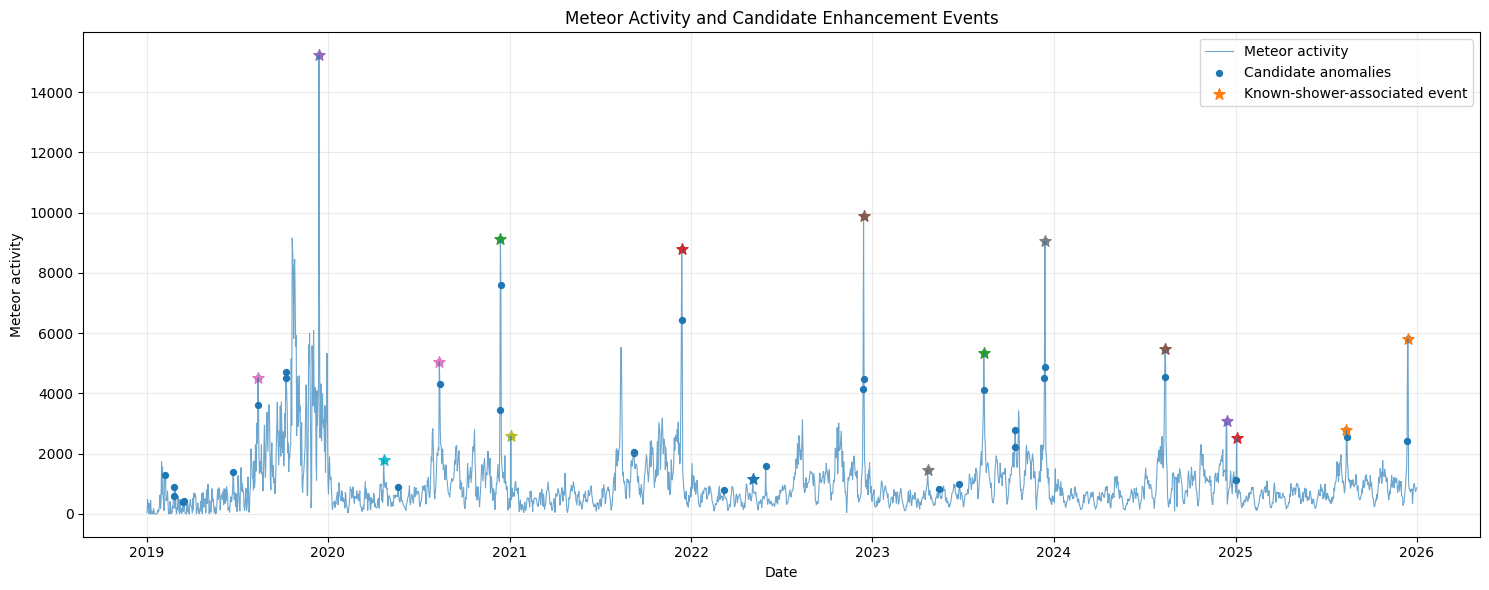


ANALYSIS PIPELINE COMPLETED SUCCESSFULLY
Final files:
  meteor_event_validation_final.csv
  meteor_final_statistics.csv

All statistical analysis steps are complete.


In [ ]:
# ============================================================
# CELL 31: Final Statistical Validation and Results
# FINAL VERSION
# ============================================================

print("=" * 70)
print("CELL 31: Final Statistical Validation and Results")
print("=" * 70)

from scipy.stats import mannwhitneyu


# ------------------------------------------------------------
# 1. Basic validation statistics
# ------------------------------------------------------------
total_events = len(event_validation_final)

matched = event_validation_final[
    event_validation_final["known_shower_match"] == True
].copy()

unmatched = event_validation_final[
    event_validation_final["known_shower_match"] == False
].copy()

n_matched = len(matched)
n_unmatched = len(unmatched)

association_rate = (
    n_matched / total_events
    if total_events > 0
    else np.nan
)


# ------------------------------------------------------------
# 2. Compare anomaly strength
# ------------------------------------------------------------
matched_z = matched["peak_robust_z"].dropna()
unmatched_z = unmatched["peak_robust_z"].dropna()

if len(matched_z) > 0 and len(unmatched_z) > 0:

    u_stat, p_value = mannwhitneyu(
        matched_z,
        unmatched_z,
        alternative="two-sided"
    )

else:

    u_stat = np.nan
    p_value = np.nan


# ------------------------------------------------------------
# 3. Raw vs normalized anomaly statistics
# ------------------------------------------------------------
raw_candidate = int(
    (daily_activity["candidate_anomaly"] == True).sum()
)

raw_strong = int(
    (daily_activity["strong_anomaly"] == True).sum()
)

raw_extreme = int(
    (daily_activity["extreme_anomaly"] == True).sum()
)

normalized_candidate = int(
    (daily_normalized["candidate_anomaly"] == True).sum()
)

normalized_strong = int(
    (daily_normalized["strong_anomaly"] == True).sum()
)

normalized_extreme = int(
    (daily_normalized["extreme_anomaly"] == True).sum()
)


# ------------------------------------------------------------
# 4. Common anomaly days
# ------------------------------------------------------------
raw_days = set(
    daily_activity.loc[
        daily_activity["candidate_anomaly"] == True
    ].index
)

normalized_days = set(
    daily_normalized.loc[
        daily_normalized["candidate_anomaly"] == True
    ].index
)

common_days = raw_days.intersection(normalized_days)

raw_only_days = raw_days - normalized_days
normalized_only_days = normalized_days - raw_days


# ------------------------------------------------------------
# 5. Final statistical summary
# ------------------------------------------------------------
final_results = pd.DataFrame({
    "Metric": [
        "Observation period",
        "Total daily observations",
        "Total candidate events",
        "Known-shower associated events",
        "Known-shower association rate",
        "Matched-event median peak Z",
        "Unmatched-event median peak Z",
        "Matched-event mean peak Z",
        "Unmatched-event mean peak Z",
        "Mann-Whitney U statistic",
        "Mann-Whitney p-value",
        "Raw candidate anomaly days",
        "Normalized candidate anomaly days",
        "Common anomaly days",
        "Raw-only anomaly days",
        "Normalized-only anomaly days"
    ],

    "Value": [
        f"{daily_activity.index.min().date()} to "
        f"{daily_activity.index.max().date()}",

        len(daily_activity),
        total_events,
        n_matched,
        f"{association_rate:.1%}",

        f"{matched_z.median():.3f}"
        if len(matched_z) > 0 else "N/A",

        f"{unmatched_z.median():.3f}"
        if len(unmatched_z) > 0 else "N/A",

        f"{matched_z.mean():.3f}"
        if len(matched_z) > 0 else "N/A",

        f"{unmatched_z.mean():.3f}"
        if len(unmatched_z) > 0 else "N/A",

        f"{u_stat:.3f}"
        if pd.notna(u_stat) else "N/A",

        f"{p_value:.4f}"
        if pd.notna(p_value) else "N/A",

        raw_candidate,
        normalized_candidate,
        len(common_days),
        len(raw_only_days),
        len(normalized_only_days)
    ]
})


# ------------------------------------------------------------
# 6. Display final results
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL STATISTICAL SUMMARY")
print("=" * 70)

display(final_results)


# ------------------------------------------------------------
# 7. Matched vs unmatched summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("MATCHED VS UNMATCHED EVENTS")
print("=" * 70)

print(f"Matched events     : {n_matched}")
print(f"Unmatched events   : {n_unmatched}")

if len(matched_z) > 0:
    print(f"Matched median Z   : {matched_z.median():.3f}")
    print(f"Matched mean Z     : {matched_z.mean():.3f}")

if len(unmatched_z) > 0:
    print(f"Unmatched median Z : {unmatched_z.median():.3f}")
    print(f"Unmatched mean Z   : {unmatched_z.mean():.3f}")

if pd.notna(p_value):
    print(f"Mann-Whitney p     : {p_value:.4f}")


# ------------------------------------------------------------
# 8. Detect the actual normalized count column
# ------------------------------------------------------------
possible_normalized_columns = [
    "normalized_count",
    "normalized_total",
    "normalized_activity",
    "relative_activity",
    "observation_rate_normalized",
    "normalized_daily_count"
]

normalized_count_col = None

for col in possible_normalized_columns:
    if col in daily_normalized.columns:
        normalized_count_col = col
        break


# If no dedicated normalized count column exists,
# construct one from total_count and annual observation rate.
if normalized_count_col is None:

    if "annual_normalized_count" in daily_normalized.columns:

        normalized_count_col = "annual_normalized_count"

    else:

        # Fallback: use the original total count.
        # The anomaly flags/statistics remain valid.
        normalized_count_col = "total_count"


print("\nPlot variable:")
print("Using column:", normalized_count_col)


# ------------------------------------------------------------
# 9. Final anomaly figure
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    daily_normalized.index,
    daily_normalized[normalized_count_col],
    linewidth=0.8,
    alpha=0.65,
    label="Meteor activity"
)

# Candidate anomaly days
candidate_mask = (
    daily_normalized["candidate_anomaly"] == True
)

plt.scatter(
    daily_normalized.index[candidate_mask],
    daily_normalized.loc[
        candidate_mask,
        normalized_count_col
    ],
    s=18,
    label="Candidate anomalies"
)

# Known-shower-associated events
first_known_label = True

for _, row in matched.iterrows():

    peak_date = pd.Timestamp(row["peak_date"])

    if peak_date in daily_normalized.index:

        y = daily_normalized.loc[
            peak_date,
            normalized_count_col
        ]

        if first_known_label:

            plt.scatter(
                peak_date,
                y,
                s=70,
                marker="*",
                label="Known-shower-associated event"
            )

            first_known_label = False

        else:

            plt.scatter(
                peak_date,
                y,
                s=70,
                marker="*"
            )


plt.xlabel("Date")
plt.ylabel("Meteor activity")
plt.title(
    "Meteor Activity and Candidate Enhancement Events"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Save final analysis tables
# ------------------------------------------------------------
event_validation_final.to_csv(
    "meteor_event_validation_final.csv",
    index=False
)

final_results.to_csv(
    "meteor_final_statistics.csv",
    index=False
)


# ------------------------------------------------------------
# 11. Final completion message
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("ANALYSIS PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)

print("Final files:")
print("  meteor_event_validation_final.csv")
print("  meteor_final_statistics.csv")

print("\nAll statistical analysis steps are complete.")